In [41]:
def find_best_sarimax_order(ts, train_end_date, full_series):
    best_mape = np.inf
    best_order = None
    best_seasonal_order = None

    ts = ts.dropna()

    # ADF testi
    try:
        adf_pvalue = adfuller(ts)[1]
        d = 0 if adf_pvalue < 0.05 else 1
    except:
        d = 0

    # ACF testi
    try:
        acf_values = acf(ts, nlags=24)
        if len(acf_values) > 12 and acf_values[12] > 0.3:
            seasonal = True
            s = 12
        else:
            seasonal = False
            s = 0
    except:
        seasonal = False
        s = 0

    for p in range(0, 3):
        for q in range(0, 3):
            try:
                if seasonal:
                    seasonal_order = (1,0,1,s)
                else:
                    seasonal_order = (0,0,0,0)

                model = SARIMAX(ts, order=(p,d,q), seasonal_order=seasonal_order,
                                enforce_stationarity=False, enforce_invertibility=False)
                results = model.fit(disp=False)

                forecast = results.get_forecast(steps=7)
                forecast_mean = forecast.predicted_mean

                test_data = full_series.loc[train_end_date:]
                common_months = test_data.index.intersection(forecast_mean.index)

                if len(common_months) == 0:
                    continue

                actual = test_data.loc[common_months]
                predicted = forecast_mean.loc[common_months]

                mape = mean_absolute_percentage_error(actual, predicted) * 100

                if mape < best_mape:
                    best_mape = mape
                    best_order = (p,d,q)
                    best_seasonal_order = seasonal_order

            except:
                continue

    if best_order is None:
        best_order = (1,0,1)
        best_seasonal_order = (0,0,0,0)
        best_mape = np.nan

    return best_order, best_seasonal_order, best_mape


Grade 'A' için seçilen SARIMAX order (MAPE bazlı): (2, 0, 0), seasonal_order: (0, 0, 0, 0), MAPE: 43.84%
                               SARIMAX Results                                
Dep. Variable:     Sipariş Mik. (TON)   No. Observations:                   30
Model:               SARIMAX(2, 0, 0)   Log Likelihood                -340.092
Date:                Thu, 22 May 2025   AIC                            686.183
Time:                        22:20:32   BIC                            690.387
Sample:                    01-01-2022   HQIC                           687.528
                         - 06-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4532      0.146      3.097      0.002       0.166       0.740
ar.L2          0.5174     

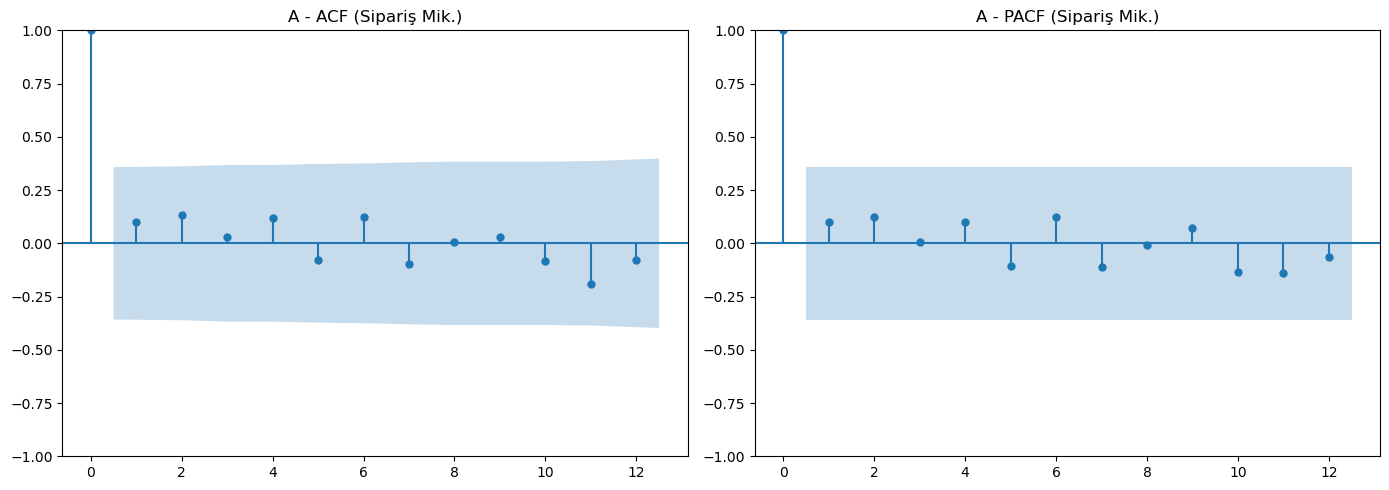

DatetimeIndex(['2024-07-01', '2024-08-01', '2024-09-01', '2024-10-01',
               '2024-11-01', '2024-12-01', '2025-01-01', '2025-02-01'],
              dtype='datetime64[ns]', freq='MS')

📈 GradeGroup 'A' için MODEL tahmini:
Gerçek: [66124.213 65682.693 76584.507 44400.889 21467.206 60007.099 18763.681
 39104.977], Tahmin: [48609.16729962 40020.89490423 43287.22888933 40323.99910185
 40671.06115951 39295.19363412 38851.22724747 37938.16078785]
MAE: 17715.14, MAPE: 44.03%


/Users/cankocak/anaconda3/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/cankocak/anaconda3/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Grade 'B' için seçilen SARIMAX order (MAPE bazlı): (0, 0, 0), seasonal_order: (0, 0, 0, 0), MAPE: 71.43%
                               SARIMAX Results                                
Dep. Variable:     Sipariş Mik. (TON)   No. Observations:                   30
Model:                        SARIMAX   Log Likelihood                -209.782
Date:                Thu, 22 May 2025   AIC                            421.564
Time:                        22:20:34   BIC                            422.965
Sample:                    01-01-2022   HQIC                           422.012
                         - 06-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2       6.94e+04   7629.757      9.095      0.000    5.44e+04    8.43e+04
Ljung-Box (L1) (Q):       

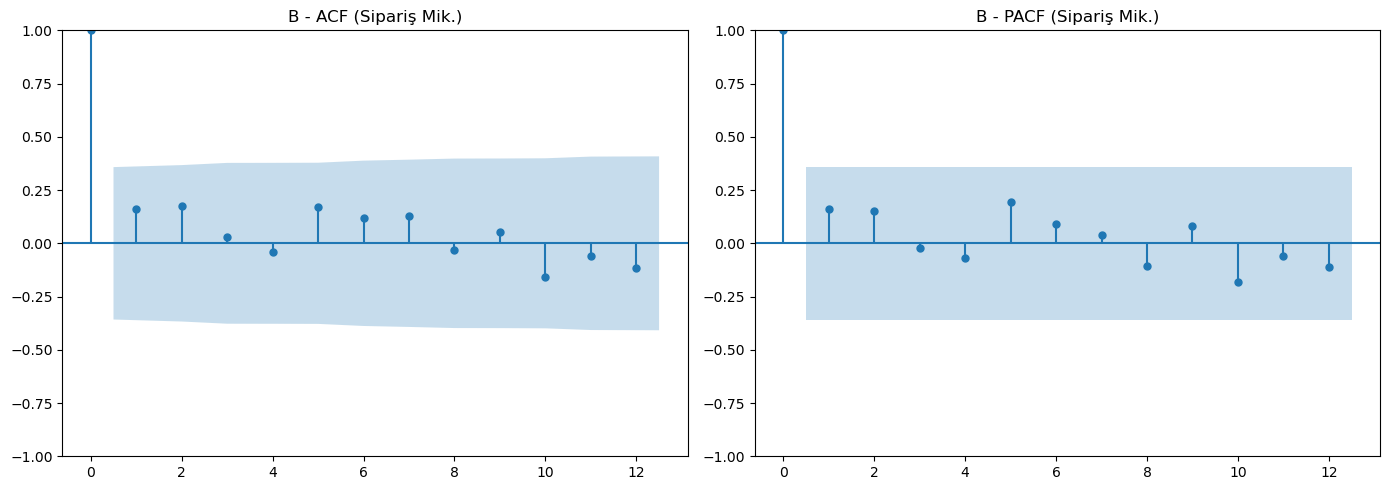

DatetimeIndex(['2024-07-01', '2024-08-01', '2024-09-01', '2024-10-01',
               '2024-11-01', '2024-12-01', '2025-01-01', '2025-02-01'],
              dtype='datetime64[ns]', freq='MS')

📈 GradeGroup 'B' için MODEL tahmini:
Gerçek: [  0.   285.68 155.2  239.58  96.31 176.     0.     0.  ], Tahmin: [0. 0. 0. 0. 0. 0. 0. 0.]
MAE: 119.10, MAPE: 62.50%
Grade 'C' için seçilen SARIMAX order (MAPE bazlı): (0, 0, 0), seasonal_order: (0, 0, 0, 0), MAPE: 14.29%
                               SARIMAX Results                                
Dep. Variable:     Sipariş Mik. (TON)   No. Observations:                   30
Model:                        SARIMAX   Log Likelihood                -243.361
Date:                Thu, 22 May 2025   AIC                            488.722
Time:                        22:20:35   BIC                            490.123
Sample:                    01-01-2022   HQIC                           489.170
                         - 06-01-2024                           

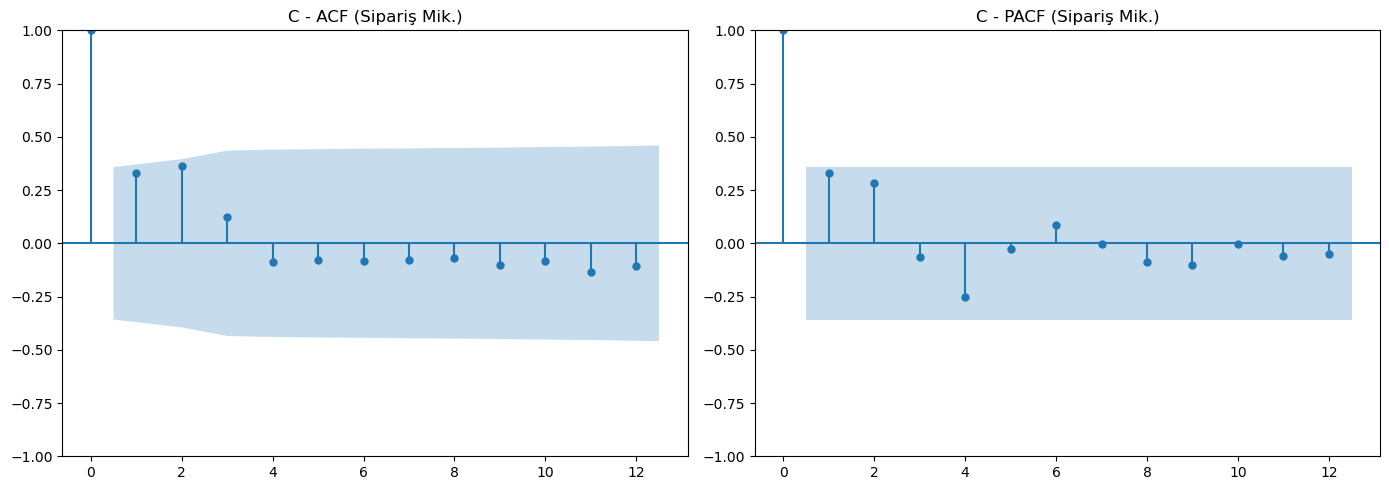

DatetimeIndex(['2024-07-01', '2024-08-01', '2024-09-01', '2024-10-01',
               '2024-11-01', '2024-12-01', '2025-01-01', '2025-02-01'],
              dtype='datetime64[ns]', freq='MS')

📈 GradeGroup 'C' için MODEL tahmini:
Gerçek: [98.06  0.    0.    0.    0.    0.    0.    0.  ], Tahmin: [0. 0. 0. 0. 0. 0. 0. 0.]
MAE: 12.26, MAPE: 12.50%
Grade 'D' için seçilen SARIMAX order (MAPE bazlı): (2, 0, 0), seasonal_order: (0, 0, 0, 0), MAPE: 65.84%
                               SARIMAX Results                                
Dep. Variable:     Sipariş Mik. (TON)   No. Observations:                   30
Model:               SARIMAX(2, 0, 0)   Log Likelihood                -269.337
Date:                Thu, 22 May 2025   AIC                            544.673
Time:                        22:20:35   BIC                            548.877
Sample:                    01-01-2022   HQIC                           546.018
                         - 06-01-2024                                    

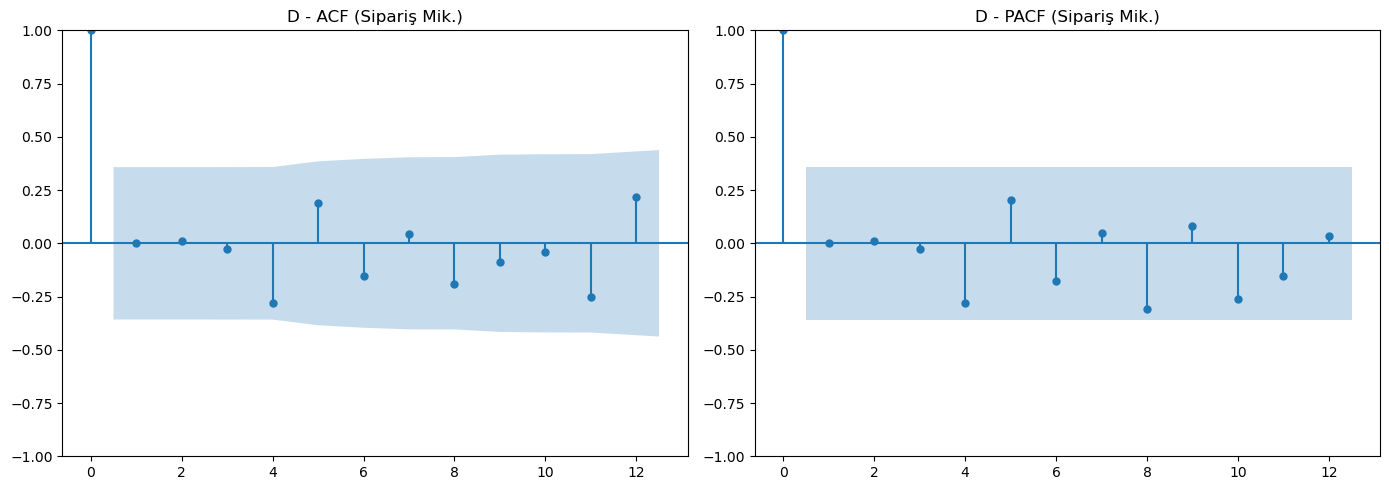

DatetimeIndex(['2024-07-01', '2024-08-01', '2024-09-01', '2024-10-01',
               '2024-11-01', '2024-12-01', '2025-01-01', '2025-02-01'],
              dtype='datetime64[ns]', freq='MS')

📈 GradeGroup 'D' için MODEL tahmini:
Gerçek: [2883.78  6150.399  466.43  2868.76  1089.    1853.165  140.382  215.9  ], Tahmin: [635.73922959 794.11066589 475.93683252 427.91814227 302.52521896
 245.45954012 183.72863546 144.09051066]
MAE: 1570.50, MAPE: 59.41%
Grade 'DD11' için seçilen SARIMAX order (MAPE bazlı): (0, 0, 0), seasonal_order: (0, 0, 0, 0), MAPE: 14.29%
                               SARIMAX Results                                
Dep. Variable:     Sipariş Mik. (TON)   No. Observations:                   30
Model:                        SARIMAX   Log Likelihood                -295.103
Date:                Thu, 22 May 2025   AIC                            592.206
Time:                        22:20:36   BIC                            593.607
Sample:                    01-01-2022   HQ

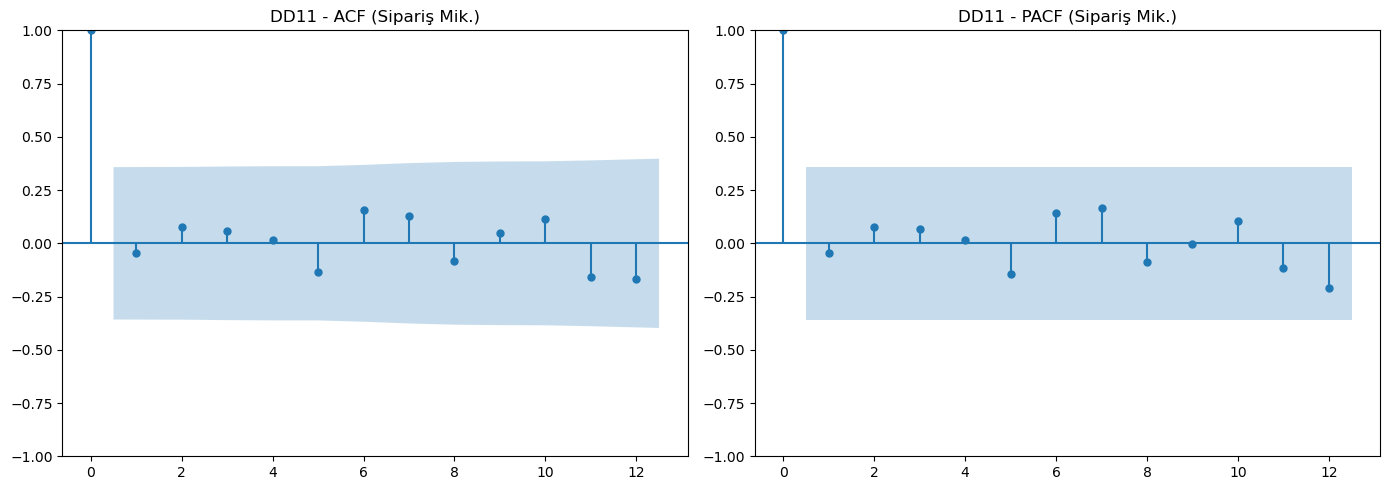

DatetimeIndex(['2024-07-01', '2024-08-01', '2024-09-01', '2024-10-01',
               '2024-11-01', '2024-12-01', '2025-01-01', '2025-02-01'],
              dtype='datetime64[ns]', freq='MS')

📈 GradeGroup 'DD11' için MODEL tahmini:
Gerçek: [ 0.    0.    0.   39.84  0.    0.    0.    0.  ], Tahmin: [0. 0. 0. 0. 0. 0. 0. 0.]
MAE: 4.98, MAPE: 12.50%
Grade 'DD11-1' için seçilen SARIMAX order (MAPE bazlı): (0, 0, 0), seasonal_order: (0, 0, 0, 0), MAPE: 0.00%
                               SARIMAX Results                                
Dep. Variable:     Sipariş Mik. (TON)   No. Observations:                   30
Model:                        SARIMAX   Log Likelihood                -318.063
Date:                Thu, 22 May 2025   AIC                            638.126
Time:                        22:20:37   BIC                            639.527
Sample:                    01-01-2022   HQIC                           638.574
                         - 06-01-2024                              

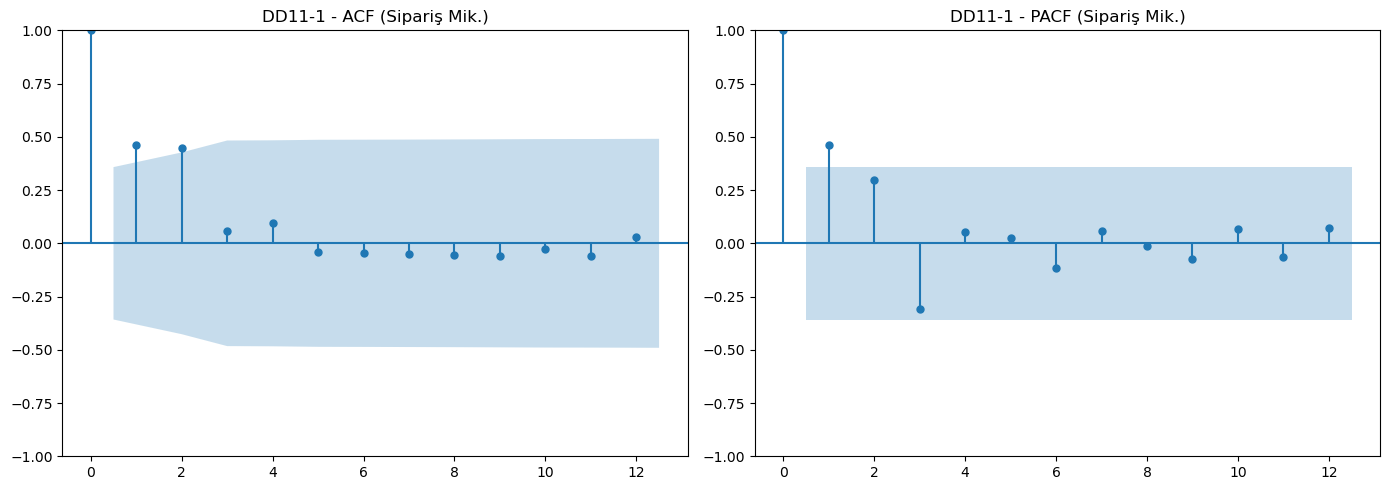

DatetimeIndex(['2024-07-01', '2024-08-01', '2024-09-01', '2024-10-01',
               '2024-11-01', '2024-12-01', '2025-01-01', '2025-02-01'],
              dtype='datetime64[ns]', freq='MS')

📈 GradeGroup 'DD11-1' için MODEL tahmini:
Gerçek: [0. 0. 0. 0. 0. 0. 0. 0.], Tahmin: [0. 0. 0. 0. 0. 0. 0. 0.]
MAE: 0.00, MAPE: 0.00%
DD11-1 için 2024-07 ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.
DD11-1 için 2024-08 ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.


/Users/cankocak/anaconda3/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Grade 'DD11-2' için seçilen SARIMAX order (MAPE bazlı): (0, 0, 0), seasonal_order: (0, 0, 0, 0), MAPE: 0.00%
                               SARIMAX Results                                
Dep. Variable:     Sipariş Mik. (TON)   No. Observations:                   30
Model:                        SARIMAX   Log Likelihood                -259.768
Date:                Thu, 22 May 2025   AIC                            521.537
Time:                        22:20:37   BIC                            522.938
Sample:                    01-01-2022   HQIC                           521.985
                         - 06-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2      1.944e+06   1.34e+05     14.507      0.000    1.68e+06    2.21e+06
Ljung-Box (L1) (Q):   

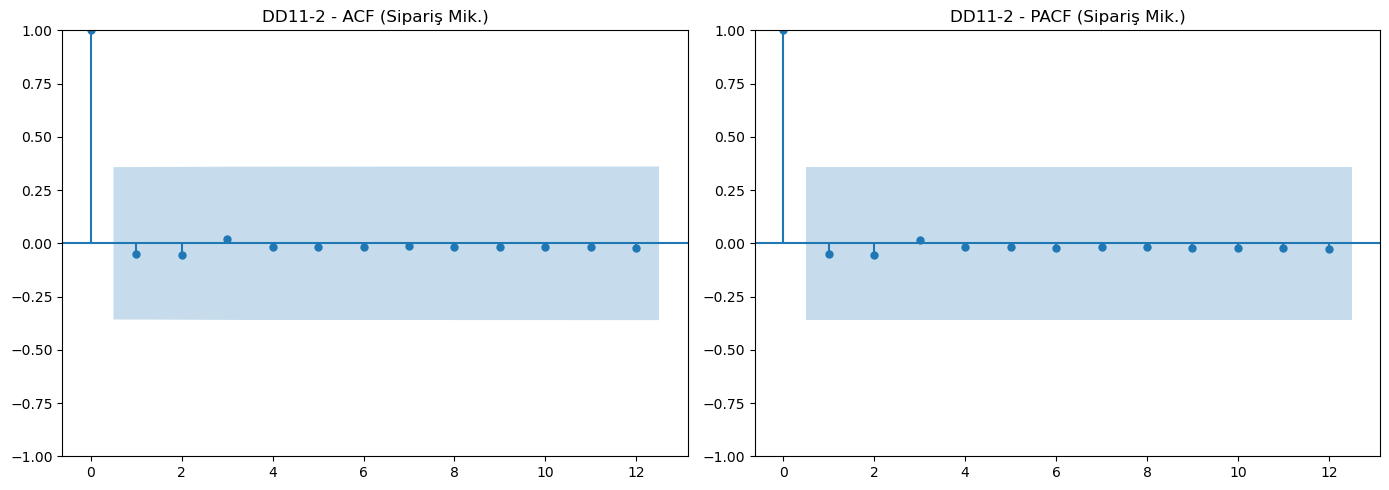

DatetimeIndex(['2024-07-01', '2024-08-01', '2024-09-01', '2024-10-01',
               '2024-11-01', '2024-12-01', '2025-01-01', '2025-02-01'],
              dtype='datetime64[ns]', freq='MS')

📈 GradeGroup 'DD11-2' için MODEL tahmini:
Gerçek: [0. 0. 0. 0. 0. 0. 0. 0.], Tahmin: [0. 0. 0. 0. 0. 0. 0. 0.]
MAE: 0.00, MAPE: 0.00%
DD11-2 için 2024-08 ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.
DD11-2 için 2024-09 ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.
DD11-2 için 2025-01 ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.
DD11-2 için 2025-02 ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.
Grade 'DD13' için seçilen SARIMAX order (MAPE bazlı): (0, 0, 0), seasonal_order: (0, 0, 0, 0), MAPE: 0.00%
                               SARIMAX Results                                
Dep. Variable:     Sipariş Mik. (TON)   No. Observations:                   30
Model:                        SARIMAX   Log Likelihood                -1

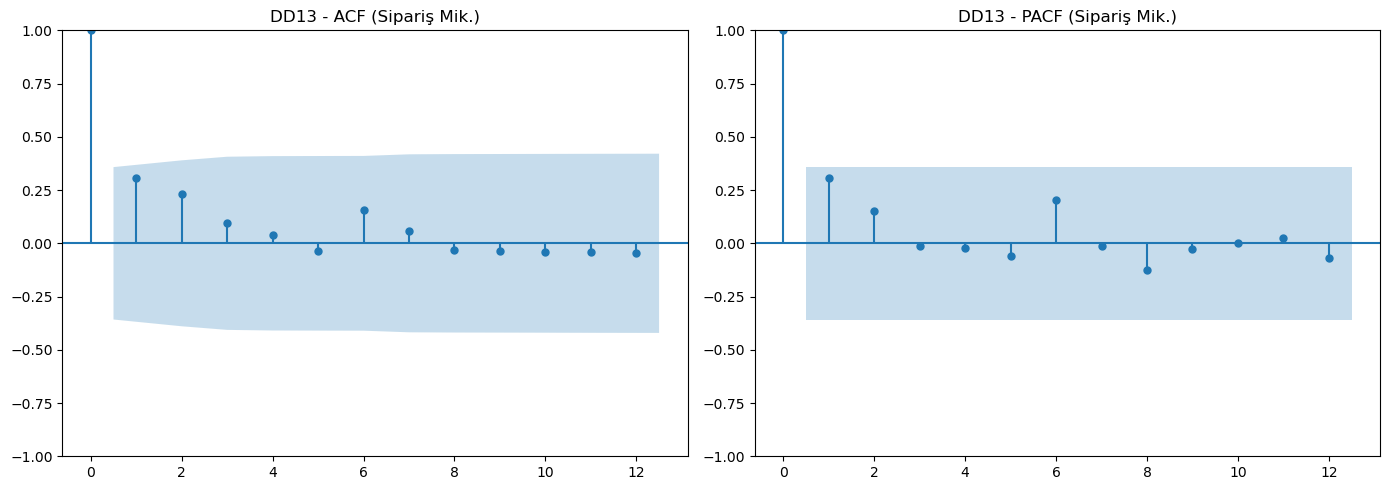

DatetimeIndex(['2024-07-01', '2024-08-01', '2024-09-01', '2024-10-01',
               '2024-11-01', '2024-12-01', '2025-01-01', '2025-02-01'],
              dtype='datetime64[ns]', freq='MS')

📈 GradeGroup 'DD13' için MODEL tahmini:
Gerçek: [0. 0. 0. 0. 0. 0. 0. 0.], Tahmin: [0. 0. 0. 0. 0. 0. 0. 0.]
MAE: 0.00, MAPE: 0.00%
Grade 'E' için seçilen SARIMAX order (MAPE bazlı): (0, 0, 0), seasonal_order: (0, 0, 0, 0), MAPE: 28.57%
                               SARIMAX Results                                
Dep. Variable:     Sipariş Mik. (TON)   No. Observations:                   30
Model:                        SARIMAX   Log Likelihood                -211.175
Date:                Thu, 22 May 2025   AIC                            424.350
Time:                        22:20:38   BIC                            425.751
Sample:                    01-01-2022   HQIC                           424.798
                         - 06-01-2024                                         
Covariance Type: 

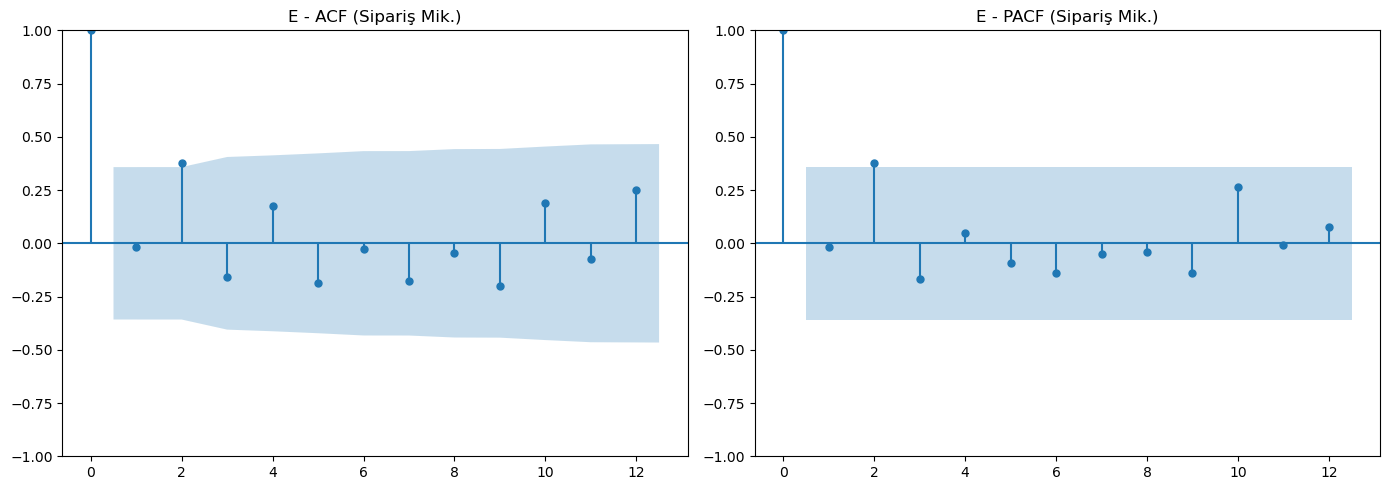

DatetimeIndex(['2024-07-01', '2024-08-01', '2024-09-01', '2024-10-01',
               '2024-11-01', '2024-12-01', '2025-01-01', '2025-02-01'],
              dtype='datetime64[ns]', freq='MS')

📈 GradeGroup 'E' için MODEL tahmini:
Gerçek: [  0.     0.     3.44   0.   196.22   0.     0.     0.  ], Tahmin: [0. 0. 0. 0. 0. 0. 0. 0.]
MAE: 24.96, MAPE: 25.00%
Grade 'P265NB' için seçilen SARIMAX order (MAPE bazlı): (0, 0, 0), seasonal_order: (0, 0, 0, 0), MAPE: 0.00%
                               SARIMAX Results                                
Dep. Variable:     Sipariş Mik. (TON)   No. Observations:                   30
Model:                        SARIMAX   Log Likelihood                -206.048
Date:                Thu, 22 May 2025   AIC                            414.095
Time:                        22:20:38   BIC                            415.497
Sample:                    01-01-2022   HQIC                           414.544
                         - 06-01-2024                        

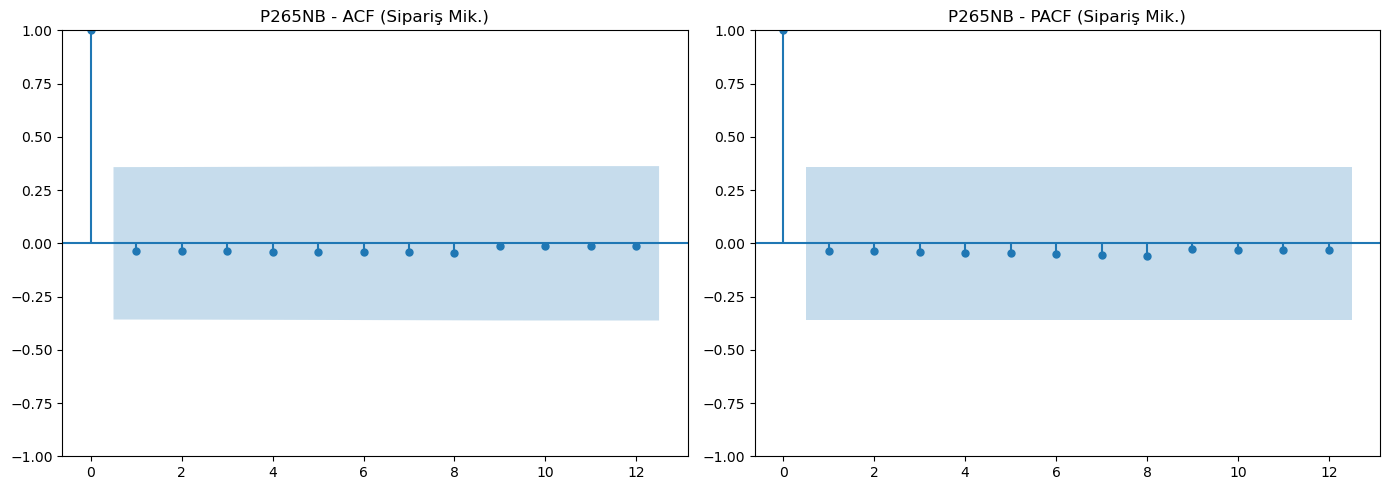

DatetimeIndex(['2024-07-01', '2024-08-01', '2024-09-01', '2024-10-01',
               '2024-11-01', '2024-12-01', '2025-01-01', '2025-02-01'],
              dtype='datetime64[ns]', freq='MS')

📈 GradeGroup 'P265NB' için MODEL tahmini:
Gerçek: [0. 0. 0. 0. 0. 0. 0. 0.], Tahmin: [0. 0. 0. 0. 0. 0. 0. 0.]
MAE: 0.00, MAPE: 0.00%
P265NB için 2024-07 ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.
P265NB için 2024-08 ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.
P265NB için 2024-10 ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.
P265NB için 2024-11 ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.
P265NB için 2024-12 ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.
P265NB için 2025-01 ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.
P265NB için 2025-02 ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.
Grade 'S235JR' için seçilen SARIMAX order (MAPE bazlı): (0, 0, 0), seasonal_order: (0

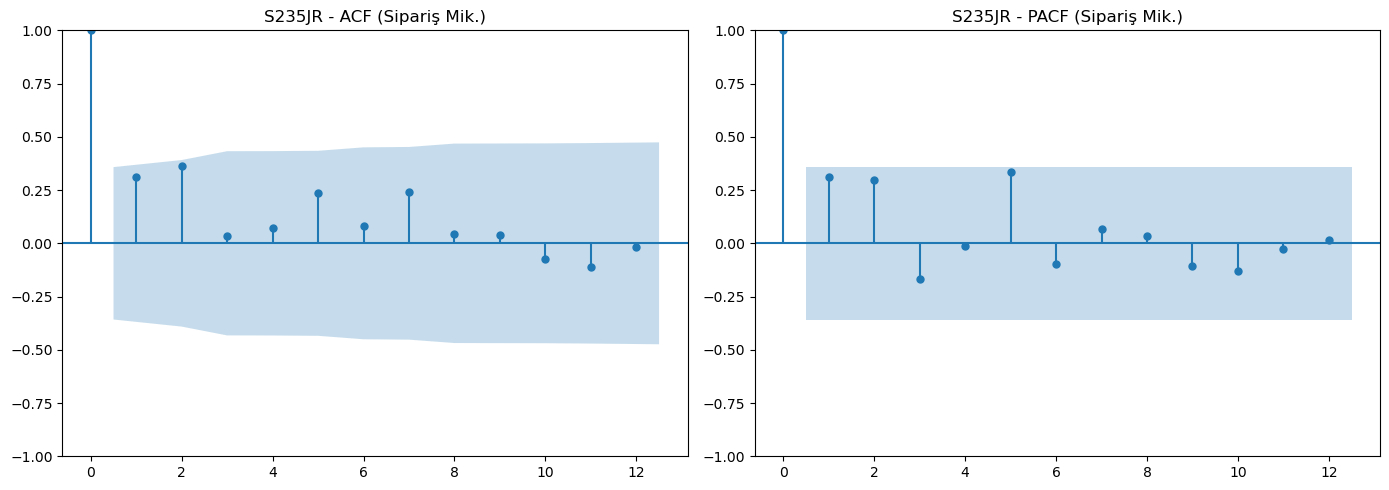

DatetimeIndex(['2024-07-01', '2024-08-01', '2024-09-01', '2024-10-01',
               '2024-11-01', '2024-12-01', '2025-01-01', '2025-02-01'],
              dtype='datetime64[ns]', freq='MS')

📈 GradeGroup 'S235JR' için MODEL tahmini:
Gerçek: [  0.     0.     0.   109.81   0.     0.     0.     0.  ], Tahmin: [0. 0. 0. 0. 0. 0. 0. 0.]
MAE: 13.73, MAPE: 12.50%
Grade 'S235JR-1' için seçilen SARIMAX order (MAPE bazlı): (0, 0, 0), seasonal_order: (0, 0, 0, 0), MAPE: 14.29%
                               SARIMAX Results                                
Dep. Variable:     Sipariş Mik. (TON)   No. Observations:                   30
Model:                        SARIMAX   Log Likelihood                -270.483
Date:                Thu, 22 May 2025   AIC                            542.965
Time:                        22:20:40   BIC                            544.366
Sample:                    01-01-2022   HQIC                           543.413
                         - 06-01-2024                

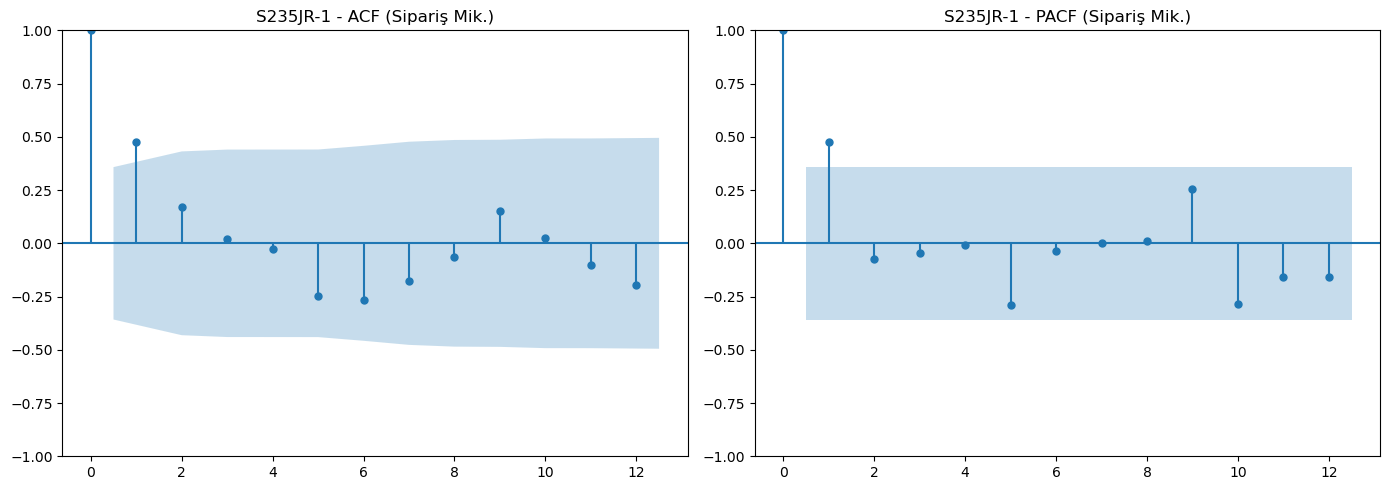

DatetimeIndex(['2024-07-01', '2024-08-01', '2024-09-01', '2024-10-01',
               '2024-11-01', '2024-12-01', '2025-01-01', '2025-02-01'],
              dtype='datetime64[ns]', freq='MS')

📈 GradeGroup 'S235JR-1' için MODEL tahmini:
Gerçek: [ 0.    0.    0.   20.91  0.    0.    0.    0.  ], Tahmin: [0. 0. 0. 0. 0. 0. 0. 0.]
MAE: 2.61, MAPE: 12.50%


/Users/cankocak/anaconda3/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/cankocak/anaconda3/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/cankocak/anaconda3/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/cankocak/anaconda3/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/cankocak/anaconda3/lib/python3.10/site-packag

Grade 'S235JR-CL3' için seçilen SARIMAX order (MAPE bazlı): (0, 0, 0), seasonal_order: (0, 0, 0, 0), MAPE: 0.00%
                               SARIMAX Results                                
Dep. Variable:     Sipariş Mik. (TON)   No. Observations:                   30
Model:                        SARIMAX   Log Likelihood                -183.458
Date:                Thu, 22 May 2025   AIC                            368.916
Time:                        22:20:41   BIC                            370.317
Sample:                    01-01-2022   HQIC                           369.364
                         - 06-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2        1.2e+04    813.676     14.748      0.000    1.04e+04    1.36e+04
Ljung-Box (L1) (Q)

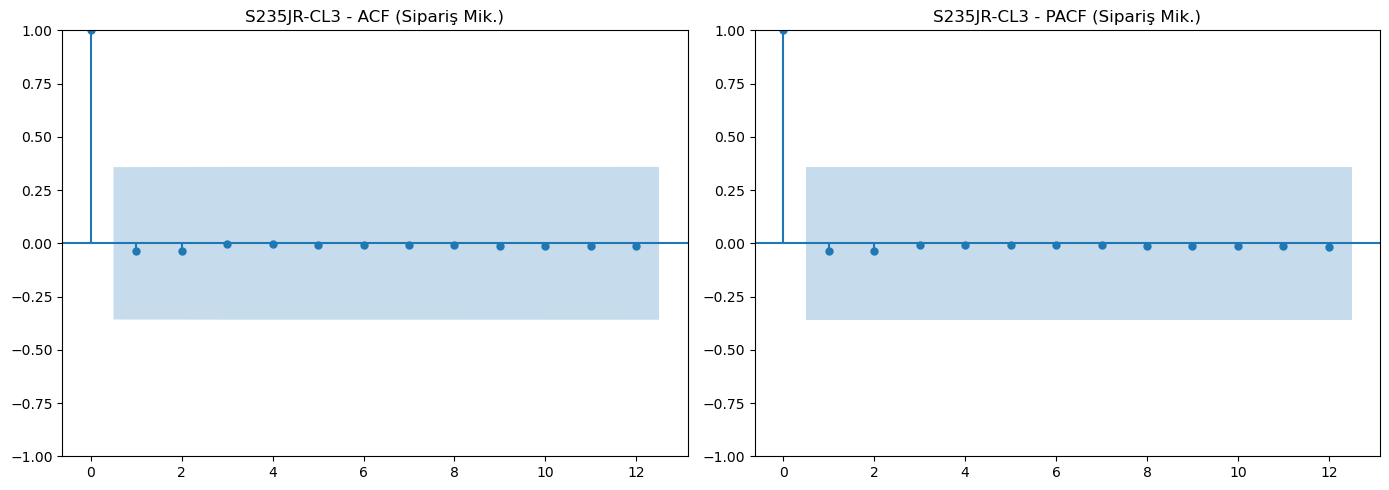

DatetimeIndex(['2024-07-01', '2024-08-01', '2024-09-01', '2024-10-01',
               '2024-11-01', '2024-12-01', '2025-01-01', '2025-02-01'],
              dtype='datetime64[ns]', freq='MS')

📈 GradeGroup 'S235JR-CL3' için MODEL tahmini:
Gerçek: [0. 0. 0. 0. 0. 0. 0. 0.], Tahmin: [0. 0. 0. 0. 0. 0. 0. 0.]
MAE: 0.00, MAPE: 0.00%
S235JR-CL3 için 2024-07 ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.
S235JR-CL3 için 2024-08 ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.
S235JR-CL3 için 2024-09 ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.
S235JR-CL3 için 2024-10 ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.
S235JR-CL3 için 2024-11 ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.
S235JR-CL3 için 2025-01 ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.
S235JR-CL3 için 2025-02 ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.


/Users/cankocak/anaconda3/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Grade 'S275J2' için seçilen SARIMAX order (MAPE bazlı): (0, 0, 1), seasonal_order: (0, 0, 0, 0), MAPE: 28.57%
                               SARIMAX Results                                
Dep. Variable:     Sipariş Mik. (TON)   No. Observations:                   30
Model:               SARIMAX(0, 0, 1)   Log Likelihood                -178.918
Date:                Thu, 22 May 2025   AIC                            361.836
Time:                        22:20:41   BIC                            364.638
Sample:                    01-01-2022   HQIC                           362.732
                         - 06-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.1614      0.279      0.577      0.564      -0.386       0.709
sigma2      8857.7152

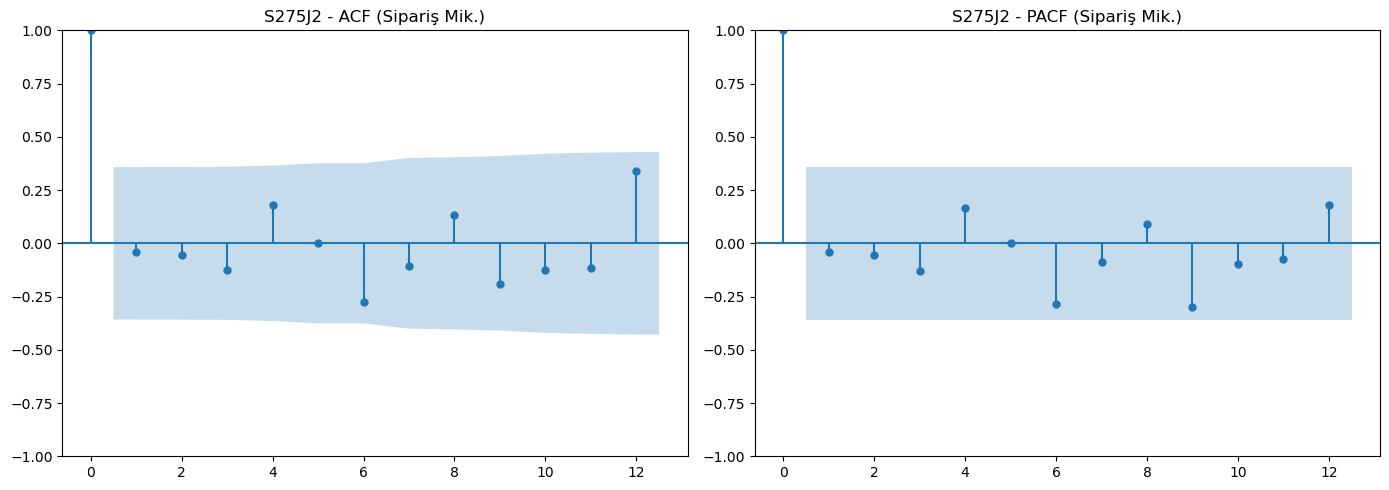

DatetimeIndex(['2024-07-01', '2024-08-01', '2024-09-01', '2024-10-01',
               '2024-11-01', '2024-12-01', '2025-01-01', '2025-02-01'],
              dtype='datetime64[ns]', freq='MS')

📈 GradeGroup 'S275J2' için MODEL tahmini:
Gerçek: [108.   0.   0.   0. 120.   0.   0.   0.], Tahmin: [0.00068418 0.         0.         0.         0.         0.
 0.         0.        ]
MAE: 28.50, MAPE: 25.00%
S275J2 için 2025-02 ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.


/Users/cankocak/anaconda3/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/cankocak/anaconda3/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Grade 'S275JR' için seçilen SARIMAX order (MAPE bazlı): (0, 0, 0), seasonal_order: (0, 0, 0, 0), MAPE: 0.00%
                               SARIMAX Results                                
Dep. Variable:     Sipariş Mik. (TON)   No. Observations:                   30
Model:                        SARIMAX   Log Likelihood                -212.368
Date:                Thu, 22 May 2025   AIC                            426.736
Time:                        22:20:42   BIC                            428.138
Sample:                    01-01-2022   HQIC                           427.185
                         - 06-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2      8.245e+04   1.11e+04      7.453      0.000    6.08e+04    1.04e+05
Ljung-Box (L1) (Q):   

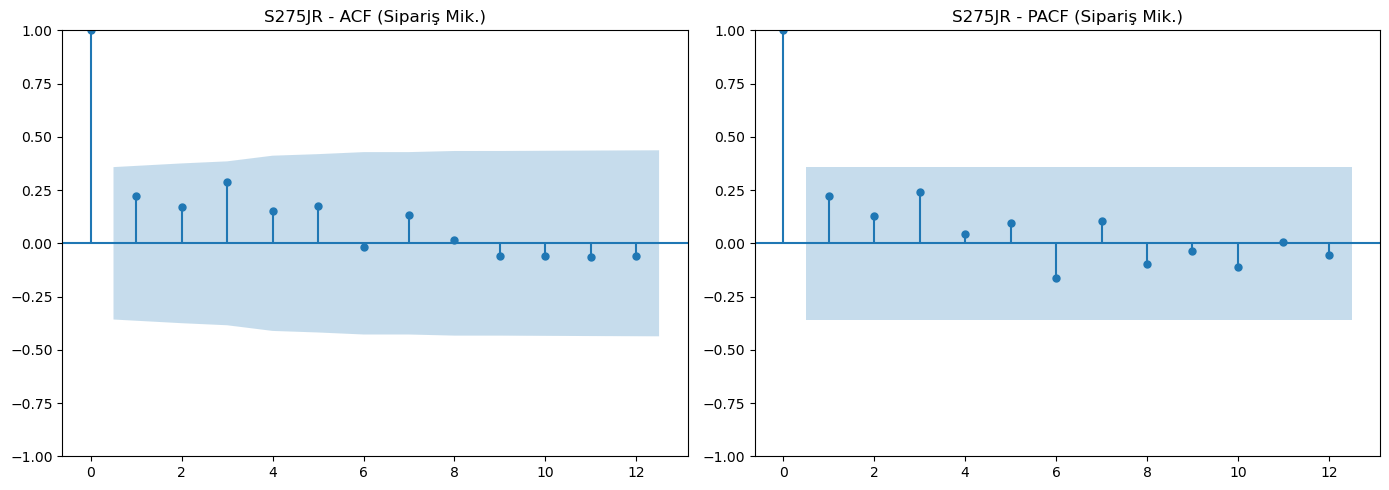

DatetimeIndex(['2024-07-01', '2024-08-01', '2024-09-01', '2024-10-01',
               '2024-11-01', '2024-12-01', '2025-01-01', '2025-02-01'],
              dtype='datetime64[ns]', freq='MS')

📈 GradeGroup 'S275JR' için MODEL tahmini:
Gerçek: [0. 0. 0. 0. 0. 0. 0. 0.], Tahmin: [0. 0. 0. 0. 0. 0. 0. 0.]
MAE: 0.00, MAPE: 0.00%
S275JR için 2024-07 ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.
S275JR için 2024-10 ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.
S275JR için 2024-11 ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.
S275JR için 2025-02 ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.


/Users/cankocak/anaconda3/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Grade 'S355J2' için seçilen SARIMAX order (MAPE bazlı): (0, 0, 0), seasonal_order: (0, 0, 0, 0), MAPE: 0.00%
                               SARIMAX Results                                
Dep. Variable:     Sipariş Mik. (TON)   No. Observations:                   30
Model:                        SARIMAX   Log Likelihood                -184.992
Date:                Thu, 22 May 2025   AIC                            371.984
Time:                        22:20:42   BIC                            373.385
Sample:                    01-01-2022   HQIC                           372.432
                         - 06-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2      1.329e+04   1103.464     12.046      0.000    1.11e+04    1.55e+04
Ljung-Box (L1) (Q):   

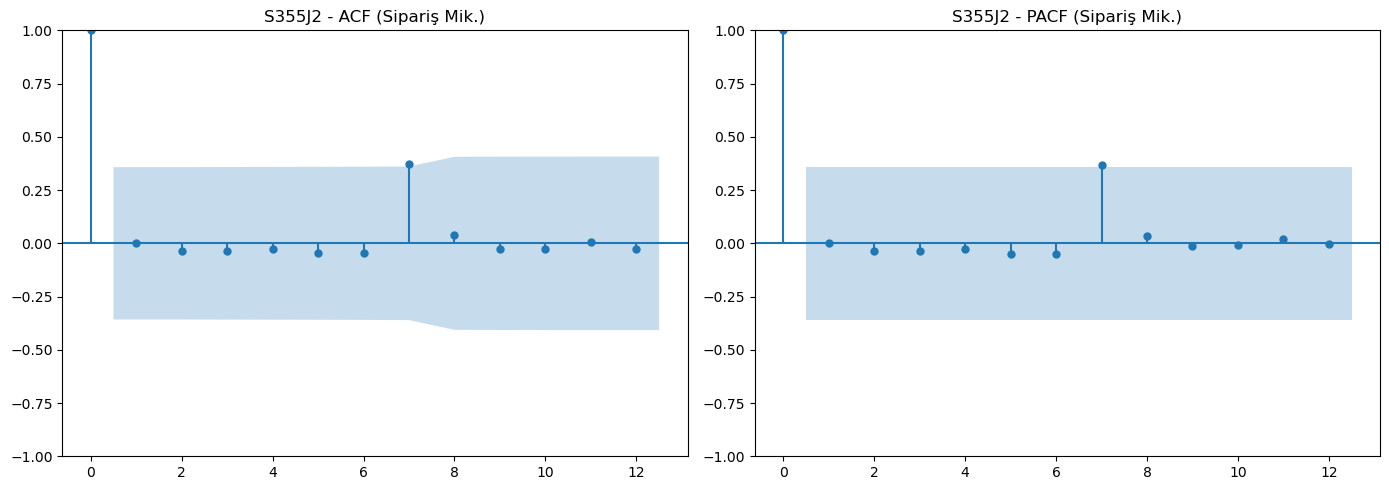

DatetimeIndex(['2024-07-01', '2024-08-01', '2024-09-01', '2024-10-01',
               '2024-11-01', '2024-12-01', '2025-01-01', '2025-02-01'],
              dtype='datetime64[ns]', freq='MS')

📈 GradeGroup 'S355J2' için MODEL tahmini:
Gerçek: [0. 0. 0. 0. 0. 0. 0. 0.], Tahmin: [0. 0. 0. 0. 0. 0. 0. 0.]
MAE: 0.00, MAPE: 0.00%
S355J2 için 2024-07 ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.
S355J2 için 2024-10 ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.
S355J2 için 2025-02 ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.


In [42]:

import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

np.set_printoptions(suppress=True)
pd.options.display.float_format = '{:,.2f}'.format

# 1. Veri yükleme
df = pd.read_excel('../preprocessedBelgeler/NewforecastData_altLimit100_son3_byGrup.xlsx')  # Dosya adını değiştir
df.columns = ['Month', 'SpecGroupId', 'Grade', 'Sipariş Mik. (TON)', 'GradeGroup']
df['Month'] = pd.to_datetime(df['Month'])
df['SpecGroupId'] = df['SpecGroupId'].astype(str)

# 2. Aylık grade bazlı toplam sipariş
monthly_grade = df.groupby(['Month', 'GradeGroup'])['Sipariş Mik. (TON)'].sum().reset_index()
grade_list = monthly_grade['GradeGroup'].unique()

# Tahminler ve dağıtılmış sonuçlar için boş dataframe
forecast_df = pd.DataFrame()
train_forecast_df = pd.DataFrame()
disaggregated_df = pd.DataFrame()
disaggregated_forecast_df = pd.DataFrame()


mae_list = []
mape_list = []

sarimax_param_log = []

# 3. Her grade için SARIMAX modeli ile tahmin
for grade in grade_list:
    # 1. Grade'e ait zaman serisini hazırla
    grade_data = monthly_grade[monthly_grade['GradeGroup'] == grade].set_index('Month')
    
    # 🔒 Model verisini 2018-01 ile 2024-12 arasında sınırla
    grade_data = grade_data.loc['2022-01':'2024-06']

    grade_ts = grade_data['Sipariş Mik. (TON)'].asfreq('MS').fillna(0)
    
    # 2. ❗ Sabit ya da boş seri kontrolü
    if grade_ts.std() < 1e-3 or grade_ts.sum() == 0:
        print(f"'{grade}' atlandı çünkü zaman serisi sabit veya boş.")
        continue  # bu grade'i atla

   

    # 3. SARIMAX Modeli
    try:
        # 🔥 Grade'e özel en iyi order'ı, seasonal order'ı ve best_mape'i bul
        full_grade_data = monthly_grade[monthly_grade['GradeGroup'] == grade].set_index('Month')  # full series data çekiyoruz
        full_grade_data = full_grade_data.loc['2022-01':'2025-02']  # geçmiş+gelecek tüm veri

        best_order, best_seasonal_order, best_mape = find_best_sarimax_order(
            grade_ts, 
            train_end_date='2024-07-01', 
            full_series=full_grade_data['Sipariş Mik. (TON)'].asfreq('MS').fillna(0)
        )

        print(f"Grade '{grade}' için seçilen SARIMAX order (MAPE bazlı): {best_order}, seasonal_order: {best_seasonal_order}, MAPE: {best_mape:.2f}%")

        # 🔥 SARIMAX Modeli kur
        model = SARIMAX(grade_ts, order=best_order, seasonal_order=best_seasonal_order)
        results = model.fit(disp=False)
        print(results.summary())
        # 🔥 Logla
        sarimax_param_log.append({
            'GradeGroup': grade,
            'Order': best_order,
            'Seasonal_Order': best_seasonal_order,
            'MAPE (%)': round(best_mape, 2)
        })



    except Exception as e:
        print(f"{grade} için model kurulamadı: {e}")
        continue

    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    plot_acf(grade_ts, lags=12, ax=ax[0])
    ax[0].set_title(f"{grade} - ACF (Sipariş Mik.)")
    
    plot_pacf(grade_ts, lags=12, ax=ax[1], method='ywm')  # 'ywm' daha stabil PACF için
    ax[1].set_title(f"{grade} - PACF (Sipariş Mik.)")

    plt.tight_layout()
    plt.show()
    
    # 4. Tahmin (örnek: 7 ay ileri)
    forecast = results.get_forecast(steps=8)
    forecast_values = forecast.predicted_mean
    forecast_index = forecast_values.index
    
    train_forecast = results.predict(start=grade_ts.index[0], end=grade_ts.index[-1])
    train_forecast_index = train_forecast.index
    
    # 🔍 Gerçek 2025 verisini al
    full_grade_data = monthly_grade[monthly_grade['GradeGroup'] == grade].set_index('Month')
    test_data = full_grade_data.loc['2024-07':'2025-02']['Sipariş Mik. (TON)'].asfreq('MS').fillna(0)
    common_months = test_data.index.intersection(forecast_index)

    print(common_months)
    if len(common_months) > 0:
        actual = test_data.loc[common_months]
        predicted = forecast_values.loc[common_months]

        mae = mean_absolute_error(actual, predicted)
        mape = mean_absolute_percentage_error(actual, predicted)

        mae_list.append({'GradeGroup': grade, 'MAE_Model': mae})
        mape_list.append({'GradeGroup': grade, 'MAPE_Model': mape})

        print(f"\n📈 GradeGroup '{grade}' için MODEL tahmini:")
        print(f"Gerçek: {actual.values}, Tahmin: {predicted.values}")
        print(f"MAE: {mae:.2f}, MAPE: {mape:.2%}")

    # 5. Forecast DataFrame'e ekle
    temp_forecast = pd.DataFrame({
        'Month': forecast_index,
        'GradeGroup': grade,
        'Forecast_TON': forecast_values.values
    })
    forecast_df = pd.concat([forecast_df, temp_forecast], ignore_index=True)
    
    temp_forecast_train = pd.DataFrame({
        'Month': train_forecast_index,
        'GradeGroup': grade,
        'Forecast_TON': train_forecast.values
    })
    train_forecast_df = pd.concat([train_forecast_df, temp_forecast_train], ignore_index=True)
    
    # 6. Disaggregation (her tahmin edilen ayı specGroupId'lere dağıt)
    for month in forecast_index:
        # Önce o grade'in geçmiş aynı aya ait oranlarını bul
        past_months = df[(df['GradeGroup'] == grade) & (df['Month'].dt.month == month.month)]
        past_months_total = past_months.groupby('SpecGroupId')['Sipariş Mik. (TON)'].sum()
        total = past_months_total.sum()
        

        # Eğer ay bazlı veri yoksa: tüm geçmişi fallback olarak kullan
        if total == 0:
            print(f"{grade} için {month.strftime('%Y-%m')} ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.")
            past_months = df[df['GradeGroup'] == grade]
            past_months_total = past_months.groupby('SpecGroupId')['Sipariş Mik. (TON)'].sum()
            total = past_months_total.sum()

        # Hâlâ yoksa atla
        if total == 0:
            print(f"{grade} için {month.strftime('%Y-%m')} ayında hiçbir geçmiş veri bulunamadı.")
            continue

        proportions = past_months_total / total
        disagg = proportions * forecast_values[month]

        for spec_id, miktar in disagg.items():
            disaggregated_df = pd.concat([disaggregated_df, pd.DataFrame({
                'Month': [month],
                'GradeGroup': [grade],
                'SpecGroupId': [spec_id],
                'Forecast_TON': [miktar]
            })])
        
        

        # 💡 SpecGroupId bazlı gerçek değerlerle kıyasla
        actual_df = df[(df['Month'] == month) & (df['GradeGroup'] == grade)]
        actual_agg = actual_df.groupby('SpecGroupId')['Sipariş Mik. (TON)'].sum()

        forecast_agg = disaggregated_df[
            (disaggregated_df['Month'] == month) &
            (disaggregated_df['GradeGroup'] == grade)
        ].groupby('SpecGroupId')['Forecast_TON'].sum()

        common_index = actual_agg.index.intersection(forecast_agg.index)

        if len(common_index) > 0:
            actual_vals = actual_agg.loc[common_index]
            pred_vals = forecast_agg.loc[common_index]

            mae_spec = mean_absolute_error(actual_vals, pred_vals)
            mape_spec = mean_absolute_percentage_error(actual_vals, pred_vals)

            # 🔁 Sonuçları listeye ekle
            for spec_id in common_index:
                disagg_metrics = {
                    'GradeGroup': grade,
                    'Month': month,
                    'SpecGroupId': spec_id,
                    'MAE_Disagg': abs(actual_vals[spec_id] - pred_vals[spec_id]),
                    'MAPE_Disagg': abs((actual_vals[spec_id] - pred_vals[spec_id]) / actual_vals[spec_id]) if actual_vals[spec_id] != 0 else np.nan
                }
                mae_list.append(disagg_metrics)


In [43]:
"""
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

np.set_printoptions(suppress=True)
pd.options.display.float_format = '{:,.2f}'.format

# 1. Veri yükleme
df = pd.read_excel('../preprocessedBelgeler/NewforecastData_altLimit100_son3_byGrup.xlsx')  # Dosya adını değiştir
df.columns = ['Month', 'SpecGroupId', 'Grade', 'Sipariş Mik. (TON)', 'GradeGroup']
df['Month'] = pd.to_datetime(df['Month'])
df['SpecGroupId'] = df['SpecGroupId'].astype(str)

# 2. Aylık grade bazlı toplam sipariş
monthly_grade = df.groupby(['Month', 'GradeGroup'])['Sipariş Mik. (TON)'].sum().reset_index()
grade_list = monthly_grade['GradeGroup'].unique()

# Tahminler ve dağıtılmış sonuçlar için boş dataframe
forecast_df = pd.DataFrame()
train_forecast_df = pd.DataFrame()
disaggregated_df = pd.DataFrame()
disaggregated_forecast_df = pd.DataFrame()


mae_list = []
mape_list = []

sarimax_param_log = []

# 3. Her grade için SARIMAX modeli ile tahmin
for grade in grade_list:
    # 1. Grade'e ait zaman serisini hazırla
    grade_data = monthly_grade[monthly_grade['GradeGroup'] == grade].set_index('Month')
    
    # 🔒 Model verisini 2018-01 ile 2024-12 arasında sınırla
    grade_data = grade_data.loc['2022-01':'2025-02']

    grade_ts = grade_data['Sipariş Mik. (TON)'].asfreq('MS').fillna(0)
    
    # 2. ❗ Sabit ya da boş seri kontrolü
    if grade_ts.std() < 1e-3 or grade_ts.sum() == 0:
        print(f"'{grade}' atlandı çünkü zaman serisi sabit veya boş.")
        continue  # bu grade'i atla

   

    # 3. SARIMAX Modeli
    try:
        # 🔥 Grade'e özel en iyi order'ı, seasonal order'ı ve best_mape'i bul
        full_grade_data = monthly_grade[monthly_grade['GradeGroup'] == grade].set_index('Month')  # full series data çekiyoruz
        full_grade_data = full_grade_data.loc['2022-01':'2025-02']  # geçmiş+gelecek tüm veri

        best_order, best_seasonal_order, best_mape = find_best_sarimax_order(
            grade_ts, 
            train_end_date='2025-03-01', 
            full_series=full_grade_data['Sipariş Mik. (TON)'].asfreq('MS').fillna(0)
        )

        print(f"Grade '{grade}' için seçilen SARIMAX order (MAPE bazlı): {best_order}, seasonal_order: {best_seasonal_order}, MAPE: {best_mape:.2f}%")

        # 🔥 SARIMAX Modeli kur
        model = SARIMAX(grade_ts, order=best_order, seasonal_order=best_seasonal_order)
        results = model.fit(disp=False)
        print(results.summary())
        # 🔥 Logla
        sarimax_param_log.append({
            'GradeGroup': grade,
            'Order': best_order,
            'Seasonal_Order': best_seasonal_order,
            'MAPE (%)': round(best_mape, 2)
        })



    except Exception as e:
        print(f"{grade} için model kurulamadı: {e}")
        continue

    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    plot_acf(grade_ts, lags=12, ax=ax[0])
    ax[0].set_title(f"{grade} - ACF (Sipariş Mik.)")
    
    plot_pacf(grade_ts, lags=12, ax=ax[1], method='ywm')  
    ax[1].set_title(f"{grade} - PACF (Sipariş Mik.)")

    plt.tight_layout()
    plt.show()
    
    # 4. Tahmin (örnek: 7 ay ileri)
    forecast = results.get_forecast(steps=3)
    forecast_values = forecast.predicted_mean
    forecast_index = forecast_values.index
    
    train_forecast = results.predict(start=grade_ts.index[0], end=grade_ts.index[-1])
    train_forecast_index = train_forecast.index
    
    
    
    # 6. Disaggregation (her tahmin edilen ayı specGroupId'lere dağıt)
    for month in forecast_index:
        # Önce o grade'in geçmiş aynı aya ait oranlarını bul
        past_months = df[(df['GradeGroup'] == grade) & (df['Month'].dt.month == month.month)]
        past_months_total = past_months.groupby('SpecGroupId')['Sipariş Mik. (TON)'].sum()
        total = past_months_total.sum()
        

        # Eğer ay bazlı veri yoksa: tüm geçmişi fallback olarak kullan
        if total == 0:
            print(f"{grade} için {month.strftime('%Y-%m')} ayında geçmiş ay bazlı oran bulunamadı. Tüm geçmişten alınacak.")
            past_months = df[df['GradeGroup'] == grade]
            past_months_total = past_months.groupby('SpecGroupId')['Sipariş Mik. (TON)'].sum()
            total = past_months_total.sum()

        # Hâlâ yoksa atla
        if total == 0:
            print(f"{grade} için {month.strftime('%Y-%m')} ayında hiçbir geçmiş veri bulunamadı.")
            continue

        proportions = past_months_total / total
        disagg = proportions * forecast_values[month]

        for spec_id, miktar in disagg.items():
            disaggregated_df = pd.concat([disaggregated_df, pd.DataFrame({
                'Month': [month],
                'GradeGroup': [grade],
                'SpecGroupId': [spec_id],
                'Forecast_TON': [miktar]
            })])
        
disaggregated_df.to_excel('../results/SARIMAX_forecast.xlsx', index=False)
       """


'\nimport pandas as pd\nimport numpy as np\nfrom statsmodels.tsa.statespace.sarimax import SARIMAX\nimport matplotlib.pyplot as plt\nfrom statsmodels.graphics.tsaplots import plot_acf, plot_pacf\n\nfrom sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error\n\nnp.set_printoptions(suppress=True)\npd.options.display.float_format = \'{:,.2f}\'.format\n\n# 1. Veri yükleme\ndf = pd.read_excel(\'../preprocessedBelgeler/NewforecastData_altLimit100_son3_byGrup.xlsx\')  # Dosya adını değiştir\ndf.columns = [\'Month\', \'SpecGroupId\', \'Grade\', \'Sipariş Mik. (TON)\', \'GradeGroup\']\ndf[\'Month\'] = pd.to_datetime(df[\'Month\'])\ndf[\'SpecGroupId\'] = df[\'SpecGroupId\'].astype(str)\n\n# 2. Aylık grade bazlı toplam sipariş\nmonthly_grade = df.groupby([\'Month\', \'GradeGroup\'])[\'Sipariş Mik. (TON)\'].sum().reset_index()\ngrade_list = monthly_grade[\'GradeGroup\'].unique()\n\n# Tahminler ve dağıtılmış sonuçlar için boş dataframe\nforecast_df = pd.DataFrame()\ntrain_foreca

In [44]:
params_df = pd.DataFrame(sarimax_param_log)
print("\n📋 Grade Bazlı SARIMAX Parametreleri ve MAPE Skorları:")
print(params_df.sort_values(by='MAPE (%)').reset_index(drop=True))

# (İstersen Excel'e aktar)
# params_df.to_excel("sarimax_parametreleri_mape.xlsx", index=False)




📋 Grade Bazlı SARIMAX Parametreleri ve MAPE Skorları:
    GradeGroup      Order Seasonal_Order  MAPE (%)
0       DD11-1  (0, 0, 0)   (0, 0, 0, 0)      0.00
1       DD11-2  (0, 0, 0)   (0, 0, 0, 0)      0.00
2         DD13  (0, 0, 0)   (0, 0, 0, 0)      0.00
3       P265NB  (0, 0, 0)   (0, 0, 0, 0)      0.00
4   S235JR-CL3  (0, 0, 0)   (0, 0, 0, 0)      0.00
5       S275JR  (0, 0, 0)   (0, 0, 0, 0)      0.00
6       S355J2  (0, 0, 0)   (0, 0, 0, 0)      0.00
7            C  (0, 0, 0)   (0, 0, 0, 0)     14.29
8         DD11  (0, 0, 0)   (0, 0, 0, 0)     14.29
9       S235JR  (0, 0, 0)   (0, 0, 0, 0)     14.29
10    S235JR-1  (0, 0, 0)   (0, 0, 0, 0)     14.29
11           E  (0, 0, 0)   (0, 0, 0, 0)     28.57
12      S275J2  (0, 0, 1)   (0, 0, 0, 0)     28.57
13           A  (2, 0, 0)   (0, 0, 0, 0)     43.84
14           D  (2, 0, 0)   (0, 0, 0, 0)     65.84
15           B  (0, 0, 0)   (0, 0, 0, 0)     71.43


In [45]:
from sklearn.metrics import mean_squared_error

# 🎯 Grade bazlı performans metriklerini hesapla
grade_metrics = []

# forecast_df: grade bazlı 3 aylık tahminlerin olduğu dataframe
# monthly_grade: gerçek değerlerin olduğu dataframe

for grade in forecast_df['GradeGroup'].unique():
    # Tahmin edilen veriler
    pred_series = forecast_df[forecast_df['GradeGroup'] == grade].set_index('Month')['Forecast_TON']
    
    # Gerçek veriler
    actual_series = monthly_grade[monthly_grade['GradeGroup'] == grade].set_index('Month')['Sipariş Mik. (TON)']
    
    # Ortak aylar
    common_months = pred_series.index.intersection(actual_series.index)
    
    if len(common_months) == 0:
        continue

    y_true = actual_series.loc[common_months]
    y_pred = pred_series.loc[common_months]

    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    smape = 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))
    wmape = 100 * np.sum(np.abs(y_pred - y_true)) / np.sum(np.abs(y_true))

    grade_metrics.append({
        'GradeGroup': grade,
        'MAE': mae,
        'MAPE (%)': mape,
        'sMAPE (%)': smape,
        'wMAPE (%)': wmape,
        'RMSE': rmse
    })

# 🎉 Sonuçları tablo olarak göster
grade_metrics_df = pd.DataFrame(grade_metrics)
print("\n📊 GradeGroup Bazlı Tahmin Performansı:")
print(grade_metrics_df)

# Excel'e kaydetmek istersen:
# grade_metrics_df.to_excel("grade_metrics_summary.xlsx", index=False)



📊 GradeGroup Bazlı Tahmin Performansı:
    GradeGroup       MAE  MAPE (%)  sMAPE (%)  wMAPE (%)      RMSE
0            A 17,715.14     44.03      40.07      36.14 20,289.40
1            B    119.10     62.50     200.00     100.00    159.43
2            C     12.26     12.50     200.00     100.00     34.67
3            D  1,570.50     59.41      95.62      80.19  2,316.02
4         DD11      4.98     12.50     200.00     100.00     14.09
5       DD11-1      0.00      0.00        NaN        NaN      0.00
6       DD11-2      0.00      0.00        NaN        NaN      0.00
7         DD13      0.00      0.00        NaN        NaN      0.00
8            E     24.96     25.00     200.00     100.00     69.38
9       P265NB      0.00      0.00        NaN        NaN      0.00
10      S235JR     13.73     12.50     200.00     100.00     38.82
11    S235JR-1      2.61     12.50     200.00     100.00      7.39
12  S235JR-CL3      0.00      0.00        NaN        NaN      0.00
13      S275J2     28.

/var/folders/pr/gmpf2b597dq2lqlfs27mkh3c0000gn/T/ipykernel_27850/4004402229.py:29: RuntimeWarning: invalid value encountered in double_scalars
  wmape = 100 * np.sum(np.abs(y_pred - y_true)) / np.sum(np.abs(y_true))
/var/folders/pr/gmpf2b597dq2lqlfs27mkh3c0000gn/T/ipykernel_27850/4004402229.py:29: RuntimeWarning: invalid value encountered in double_scalars
  wmape = 100 * np.sum(np.abs(y_pred - y_true)) / np.sum(np.abs(y_true))
/var/folders/pr/gmpf2b597dq2lqlfs27mkh3c0000gn/T/ipykernel_27850/4004402229.py:29: RuntimeWarning: invalid value encountered in double_scalars
  wmape = 100 * np.sum(np.abs(y_pred - y_true)) / np.sum(np.abs(y_true))
/var/folders/pr/gmpf2b597dq2lqlfs27mkh3c0000gn/T/ipykernel_27850/4004402229.py:29: RuntimeWarning: invalid value encountered in double_scalars
  wmape = 100 * np.sum(np.abs(y_pred - y_true)) / np.sum(np.abs(y_true))
/var/folders/pr/gmpf2b597dq2lqlfs27mkh3c0000gn/T/ipykernel_27850/4004402229.py:29: RuntimeWarning: invalid value encountered in double_s

In [46]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

# 🎯 Tüm Grade'ler için genel hata metrikleri
# forecast_df: tahminler (2025-01 ~ 2025-03)
# monthly_grade: gerçek değerler

# Gerçek veriyi 2025-01 ile 2025-03 arasından alalım
actual_all = monthly_grade[
    (monthly_grade['Month'] >= '2024-07') & 
    (monthly_grade['Month'] <= '2025-02')
]

# Tahmin edilen veriler zaten forecast_df içinde (her Grade için)
merged_all = pd.merge(
    actual_all, 
    forecast_df, 
    on=['Month', 'GradeGroup'], 
    how='inner'
)

# Boş varsa at
merged_all.dropna(subset=['Sipariş Mik. (TON)', 'Forecast_TON'], inplace=True)
print(merged_all)
# Gerçek ve tahmin serileri
y_true_all = merged_all['Sipariş Mik. (TON)']
y_pred_all = merged_all['Forecast_TON']

# Hata metrikleri
mae_all = mean_absolute_error(y_true_all, y_pred_all)
mape_all = mean_absolute_percentage_error(y_true_all, y_pred_all) * 100
rmse_all = np.sqrt(mean_squared_error(y_true_all, y_pred_all))
smape_all = 100 * np.mean(2 * np.abs(y_pred_all - y_true_all) / (np.abs(y_true_all) + np.abs(y_pred_all)))
wmape_all = 100 * np.sum(np.abs(y_pred_all - y_true_all)) / np.sum(np.abs(y_true_all))

# 📢 Sonuçları yazdır
print("\n📦 Tüm GradeGroup'lar için TOPLAM tahmin performansı:")
print(f"MAE   : {mae_all:.2f}")
print(f"MAPE  : {mape_all:.2f}%")
print(f"sMAPE : {smape_all:.2f}%")
print(f"wMAPE : {wmape_all:.2f}%")
print(f"RMSE  : {rmse_all:.2f}")


         Month  GradeGroup  Sipariş Mik. (TON)  Forecast_TON
0   2024-07-01           A           66,124.21     48,609.17
1   2024-07-01           B                0.00          0.00
2   2024-07-01           C               98.06          0.00
3   2024-07-01           D            2,883.78        635.74
4   2024-07-01        DD11                0.00          0.00
..         ...         ...                 ...           ...
123 2025-02-01    S235JR-1                0.00          0.00
124 2025-02-01  S235JR-CL3                0.00          0.00
125 2025-02-01      S275J2                0.00          0.00
126 2025-02-01      S275JR                0.00          0.00
127 2025-02-01      S355J2                0.00          0.00

[128 rows x 4 columns]

📦 Tüm GradeGroup'lar için TOPLAM tahmin performansı:
MAE   : 1218.24
MAPE  : 16.62%
sMAPE : 127.09%
wMAPE : 38.08%
RMSE  : 5105.51


⏳ 2024-07 ayı için grafik hazırlanıyor...


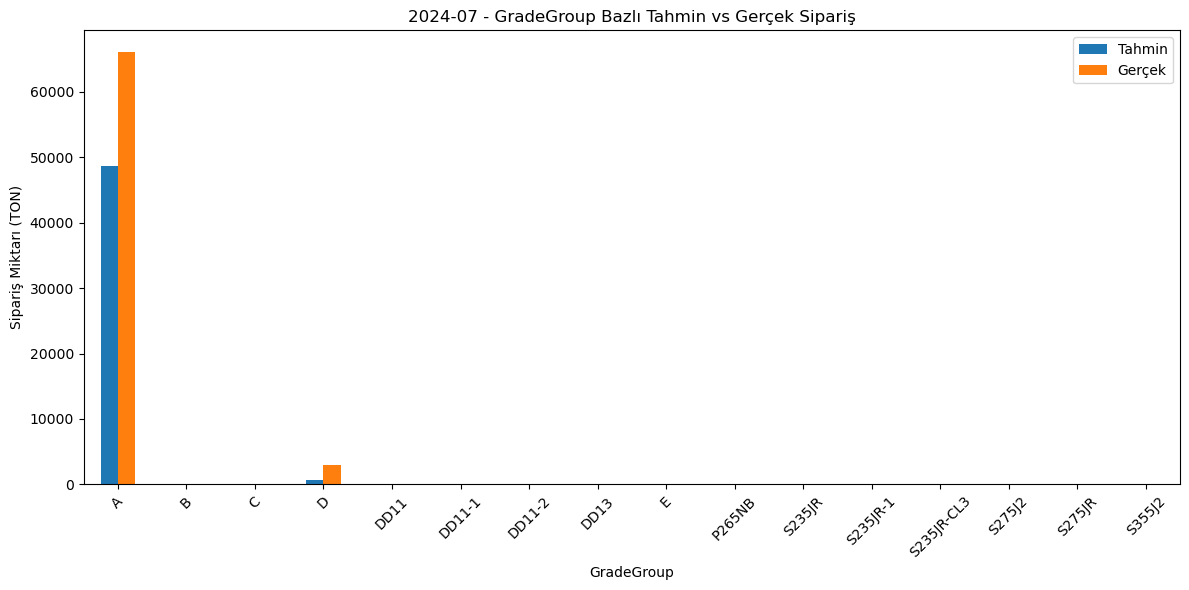

⏳ 2024-08 ayı için grafik hazırlanıyor...


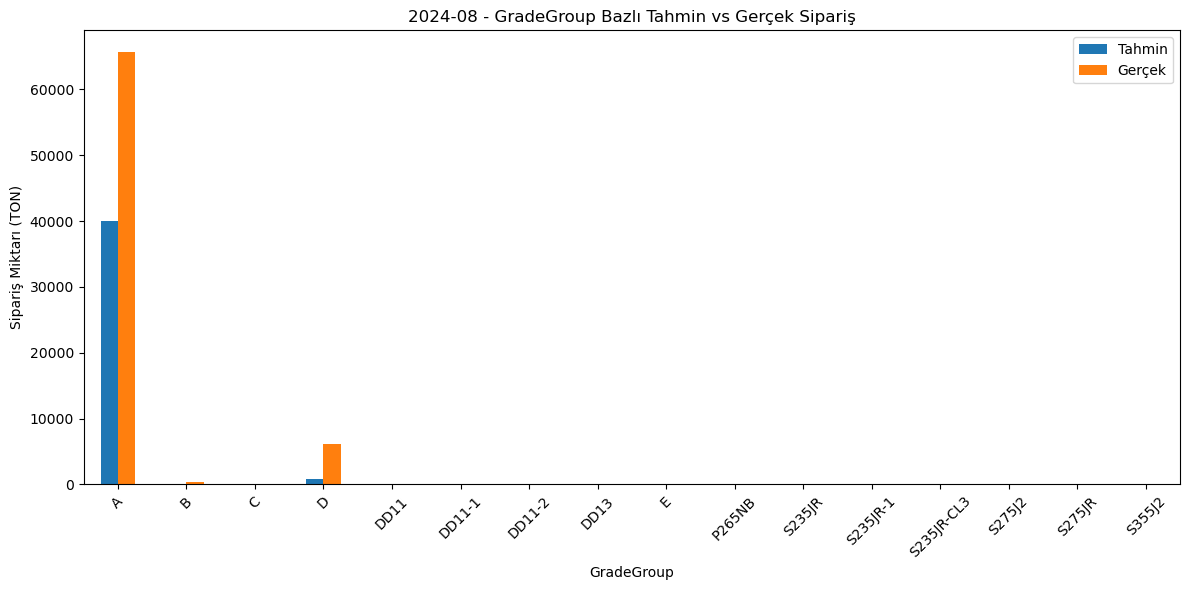

⏳ 2024-09 ayı için grafik hazırlanıyor...


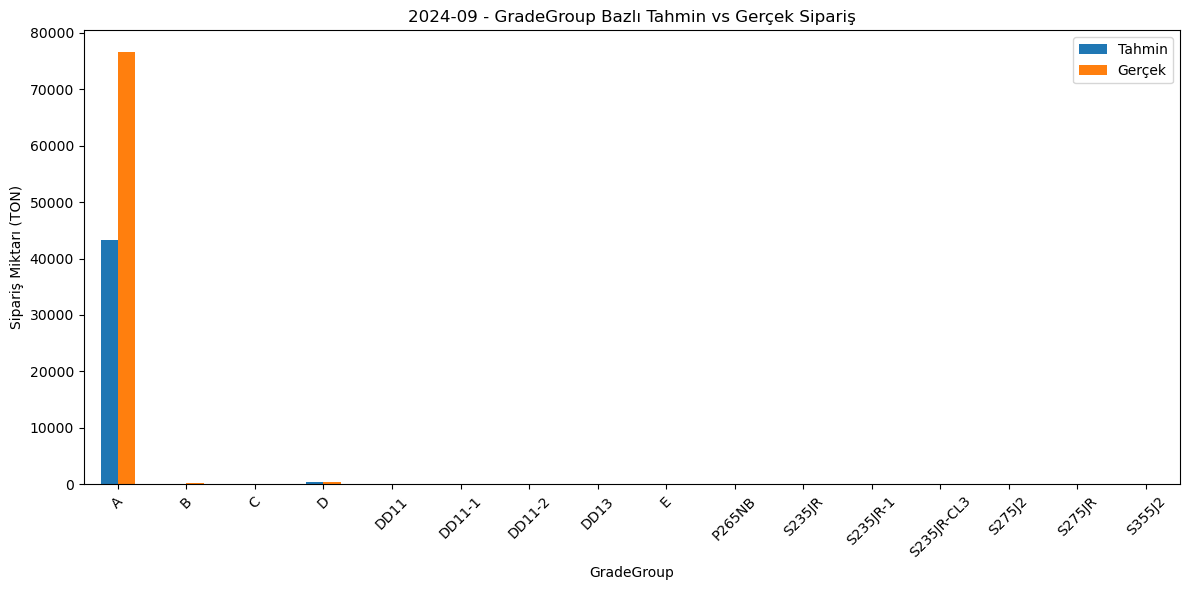

⏳ 2024-10 ayı için grafik hazırlanıyor...


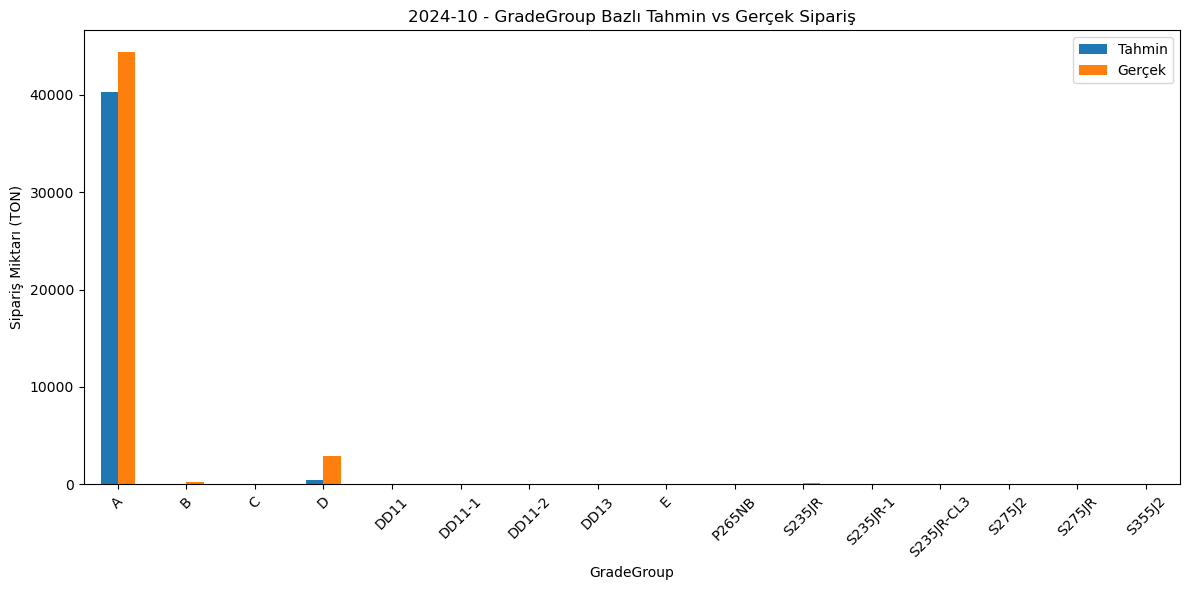

⏳ 2024-11 ayı için grafik hazırlanıyor...


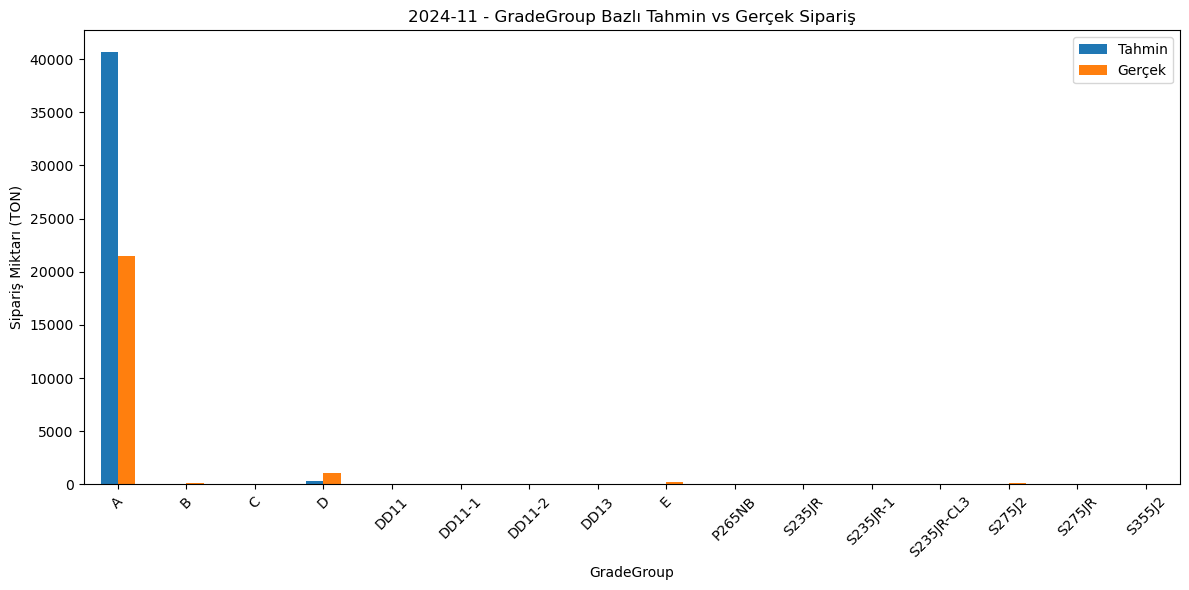

⏳ 2024-12 ayı için grafik hazırlanıyor...


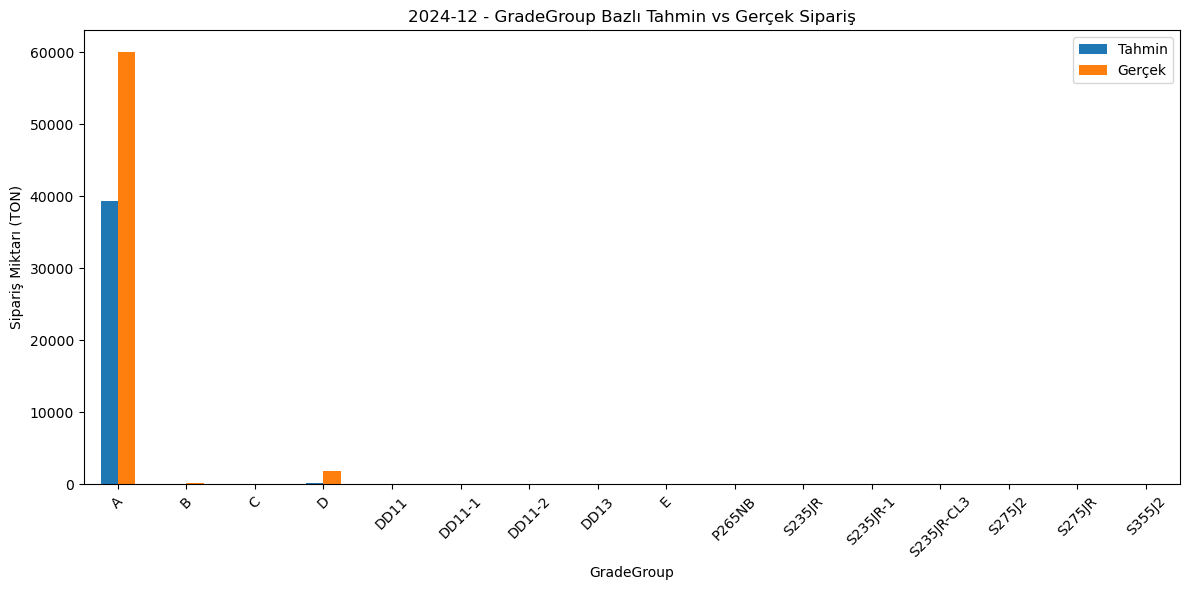

⏳ 2025-01 ayı için grafik hazırlanıyor...


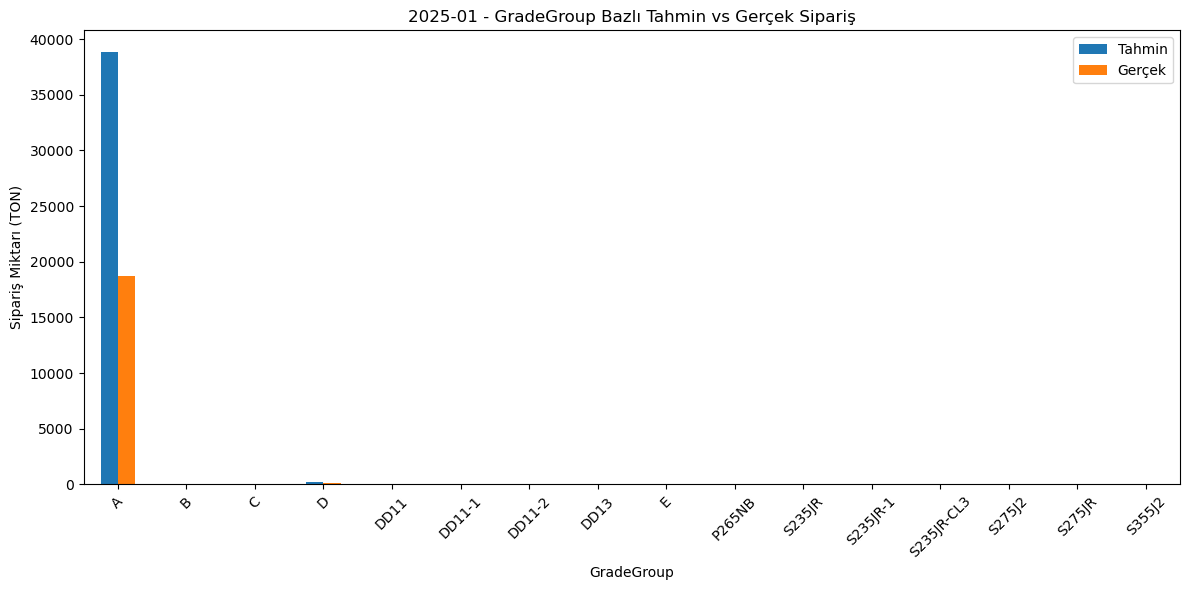

⏳ 2025-02 ayı için grafik hazırlanıyor...


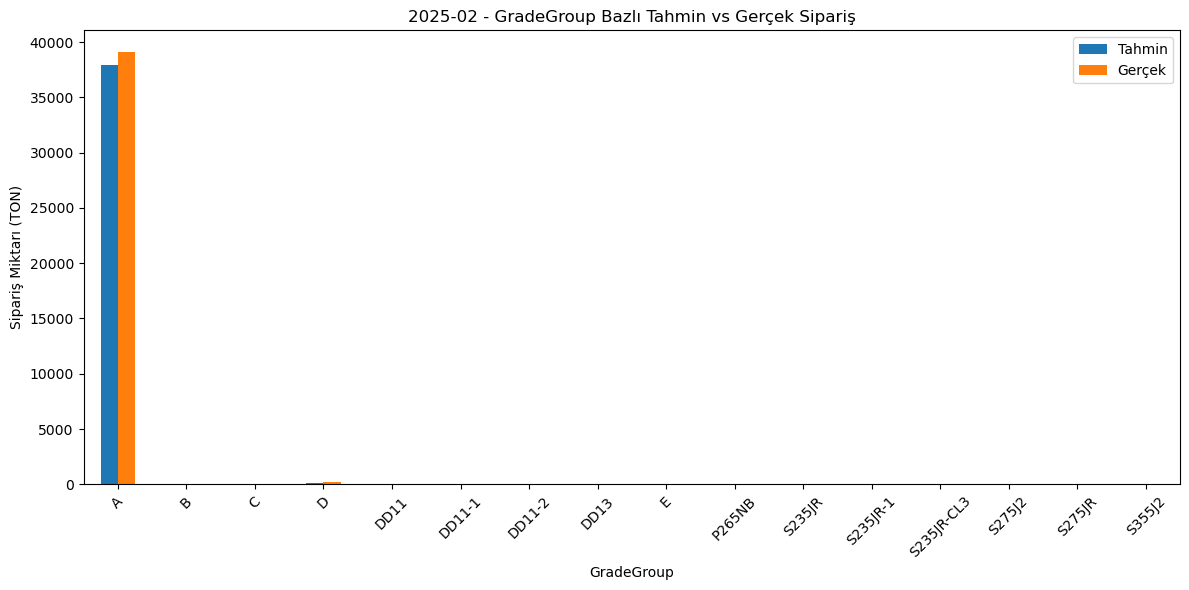

In [47]:
import matplotlib.pyplot as plt

# 🎯 Hedef aylar
target_months = ['2024-07','2024-08', '2024-09', '2024-10','2024-11','2024-12','2025-01','2025-02']

for month in target_months:
    print(f"⏳ {month} ayı için grafik hazırlanıyor...")

    forecast_m = forecast_df[forecast_df['Month'] == month]
    actual_m = monthly_grade[monthly_grade['Month'] == month]

    # Verileri aynı forma sok
    forecast_m = forecast_m[['GradeGroup', 'Forecast_TON']].set_index('GradeGroup')
    actual_m = actual_m[['GradeGroup', 'Sipariş Mik. (TON)']].set_index('GradeGroup')

    # Ortak grade'leri al
    common_grades = forecast_m.index.intersection(actual_m.index)

    if len(common_grades) == 0:
        print(f"⚠️ {month} için hem tahmin hem gerçek veri yok.")
        continue

    compare_df = pd.DataFrame({
        'Forecast': forecast_m.loc[common_grades]['Forecast_TON'],
        'Actual': actual_m.loc[common_grades]['Sipariş Mik. (TON)']
    }).sort_index()

    # Bar chart
    colors = ['red' if x == 'Forecast' else 'grey' for x in compare_df.columns]
    compare_df.plot(kind='bar', color=colors, figsize=(12,6))
    plt.title(f"{month} - GradeGroup Bazlı Tahmin vs Gerçek Sipariş")
    plt.ylabel("Sipariş Miktarı (TON)")
    plt.xlabel("GradeGroup")
    plt.xticks(rotation=45)
    plt.legend(["Tahmin", "Gerçek"])
    plt.tight_layout()
    plt.show()



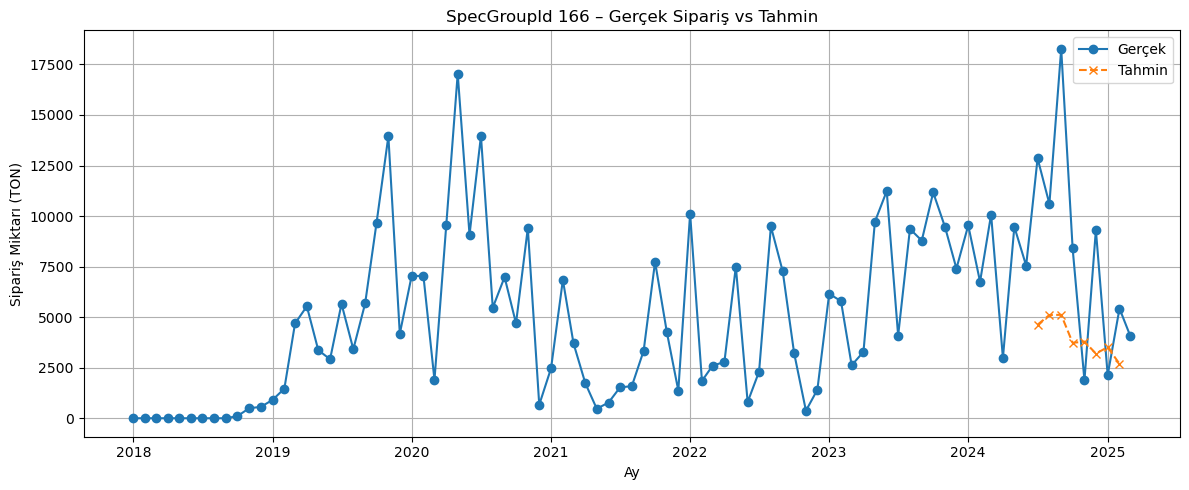

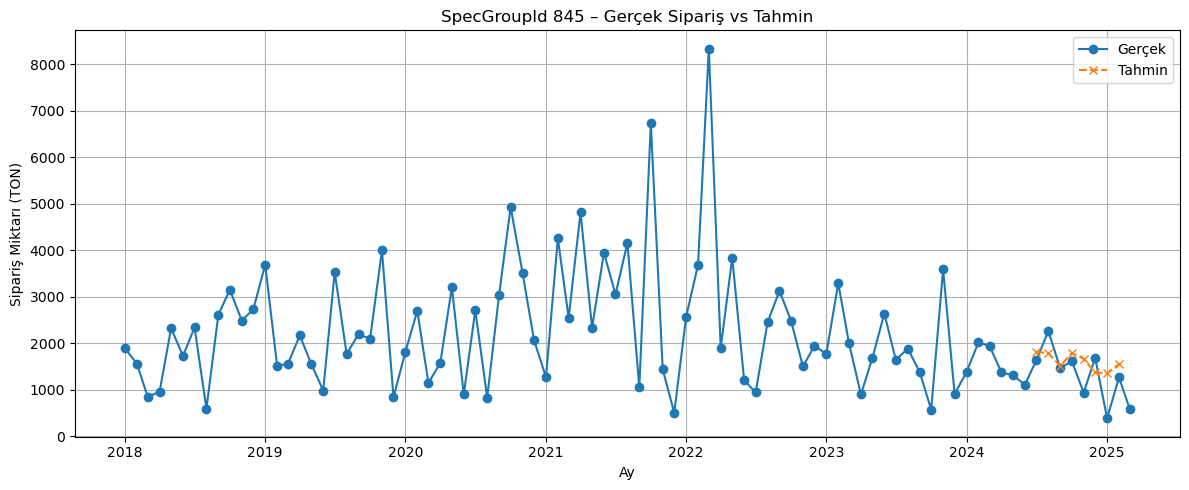

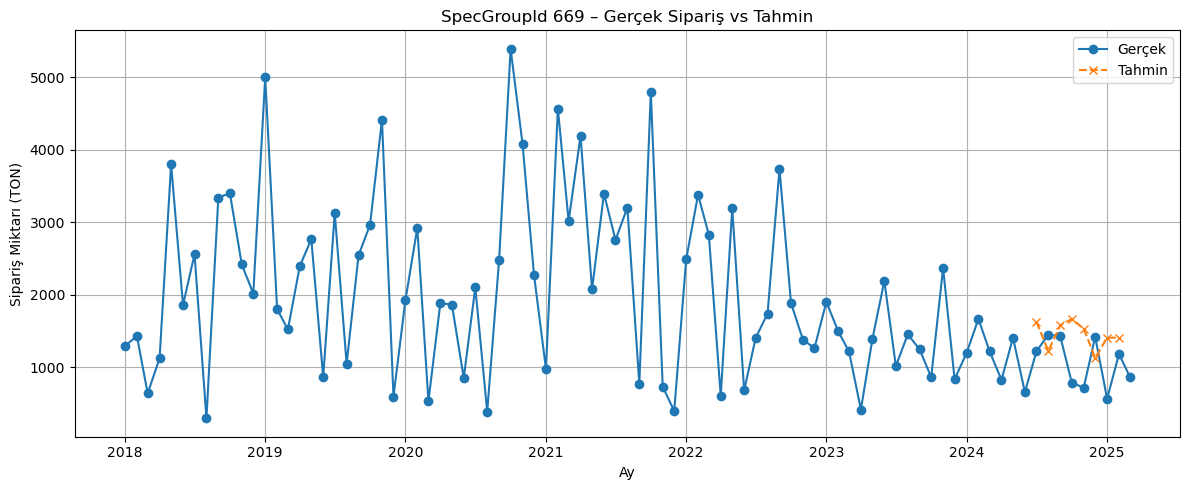

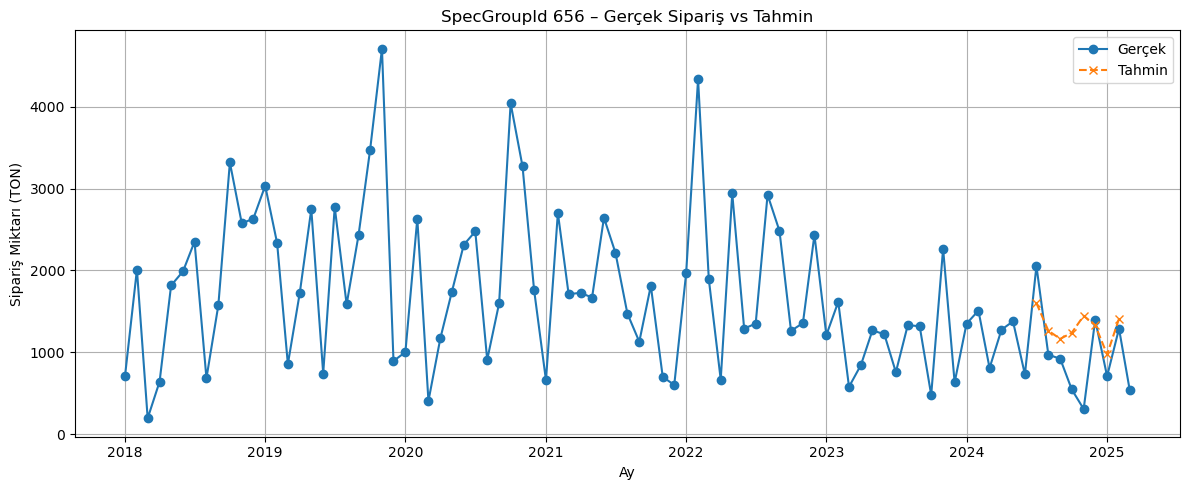

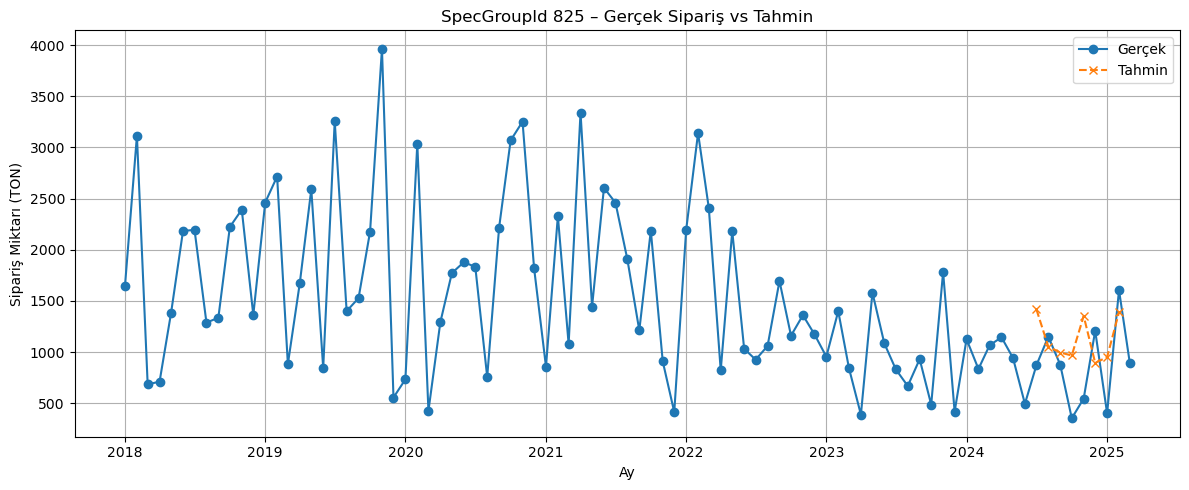

  SpecGroupId      MAE  MAPE (%)  sMAPE (%)  wMAPE (%)     RMSE
0         166 5,461.54     65.83      79.41      63.44 6,549.83
1         845   395.82     51.73      31.85      28.13   491.07
2         669   478.88     58.80      40.51      43.57   560.11
3         656   409.35     78.58      40.94      39.98   526.48
4         825   407.66     72.85      46.61      46.52   473.82


/var/folders/pr/gmpf2b597dq2lqlfs27mkh3c0000gn/T/ipykernel_27850/4268786290.py:70: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  metrics_df = metrics_df.append({'SpecGroupId': spec_id,
/var/folders/pr/gmpf2b597dq2lqlfs27mkh3c0000gn/T/ipykernel_27850/4268786290.py:70: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  metrics_df = metrics_df.append({'SpecGroupId': spec_id,
/var/folders/pr/gmpf2b597dq2lqlfs27mkh3c0000gn/T/ipykernel_27850/4268786290.py:70: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  metrics_df = metrics_df.append({'SpecGroupId': spec_id,
/var/folders/pr/gmpf2b597dq2lqlfs27mkh3c0000gn/T/ipykernel_27850/4268786290.py:70: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a futur

In [48]:
import matplotlib.pyplot as plt

# 🎯 Seçmek istediğin SpecGroupId’leri belirle
selected_spec_ids = [ '166', '845', '669','656','825' ]  # buraya ilgilendiğin ID'leri yaz

for spec_id in selected_spec_ids:
    # 🔹 Gerçek veriler (geçmiş)
    actual_series = df[df['SpecGroupId'] == spec_id][['Month', 'Sipariş Mik. (TON)']].copy()
    actual_series = actual_series.groupby('Month').sum().sort_index()
    actual_series.rename(columns={'Sipariş Mik. (TON)': 'Actual'}, inplace=True)

    # 🔹 Tahmin verileri (disaggregated)
    forecast_series = disaggregated_df[disaggregated_df['SpecGroupId'] == spec_id][['Month', 'Forecast_TON']].copy()
    forecast_series = forecast_series.groupby('Month').sum().sort_index()
    forecast_series.rename(columns={'Forecast_TON': 'Forecast'}, inplace=True)

    
    # 🔗 İki veri setini birleştir
    merged = pd.concat([actual_series, forecast_series], axis=1)

    # 📈 Grafik
    plt.figure(figsize=(12, 5))
    colors = ['red' if x == 'Actual' else 'grey' for x in merged.columns]
    plt.plot(merged.index, merged['Actual'], label='Gerçek', marker='o')
    plt.plot(merged.index, merged['Forecast'], label='Tahmin', linestyle='--', marker='x')
    plt.title(f"SpecGroupId {spec_id} – Gerçek Sipariş vs Tahmin")
    plt.xlabel("Ay")
    plt.ylabel("Sipariş Miktarı (TON)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error

# 🎯 Seçmek istediğin SpecGroupId’leri belirle
selected_spec_ids = ['166', '845', '669','656','825']

# Sonuçları saklamak için boş DataFrame oluştur
metrics_df = pd.DataFrame(columns=['SpecGroupId', 'MAE', 'MAPE (%)', 'sMAPE (%)', 'wMAPE (%)', 'RMSE'])

for spec_id in selected_spec_ids:
    # 🔹 Gerçek veriler (geçmiş)
    actual_series = df[df['SpecGroupId'] == spec_id][['Month', 'Sipariş Mik. (TON)']].copy()
    actual_series = actual_series.groupby('Month').sum().sort_index()
    actual_series.rename(columns={'Sipariş Mik. (TON)': 'Actual'}, inplace=True)

    # 🔹 Tahmin verileri (disaggregated)
    forecast_series = disaggregated_df[disaggregated_df['SpecGroupId'] == spec_id][['Month', 'Forecast_TON']].copy()
    forecast_series = forecast_series.groupby('Month').sum().sort_index()
    forecast_series.rename(columns={'Forecast_TON': 'Forecast'}, inplace=True)

    # 🔗 İki veri setini birleştir ve NaN değerleri kaldır
    merged = pd.concat([actual_series, forecast_series], axis=1).dropna()

    # 📌 Hata metriklerini hesapla
    mae = mean_absolute_error(merged['Actual'], merged['Forecast'])
    mape = mean_absolute_percentage_error(merged['Actual'], merged['Forecast']) * 100
    rmse = np.sqrt(mean_squared_error(merged['Actual'], merged['Forecast']))

    # sMAPE hesapla
    smape = 100 * np.mean(2 * np.abs(merged['Forecast'] - merged['Actual']) / (np.abs(merged['Actual']) + np.abs(merged['Forecast'])))

    # wMAPE hesapla
    wmape = 100 * np.sum(np.abs(merged['Forecast'] - merged['Actual'])) / np.sum(np.abs(merged['Actual']))

    # Sonuçları DataFrame'e ekle
    metrics_df = metrics_df.append({'SpecGroupId': spec_id,
                                    'MAE': mae,
                                    'MAPE (%)': mape,
                                    'sMAPE (%)': smape,
                                    'wMAPE (%)': wmape,
                                    'RMSE': rmse}, ignore_index=True)

# 📊 Sonuçları göster
print(metrics_df)



In [49]:
# 🔁 Eğer tüm SpecGroupId'ler için metrik hesaplanmadıysa onları da hesaplayalım
if len(metrics_df) < df['SpecGroupId'].nunique():
    all_spec_ids = df['SpecGroupId'].astype(str).unique()
    for spec_id in all_spec_ids:
        if spec_id in metrics_df['SpecGroupId'].astype(str).values:
            continue  # zaten hesaplandıysa atla

        actual_series = df[df['SpecGroupId'].astype(str) == spec_id][['Month', 'Sipariş Mik. (TON)']].copy()
        actual_series = actual_series.groupby('Month').sum().sort_index()
        actual_series.rename(columns={'Sipariş Mik. (TON)': 'Actual'}, inplace=True)

        forecast_series = disaggregated_df[disaggregated_df['SpecGroupId'].astype(str) == spec_id][['Month', 'Forecast_TON']].copy()
        forecast_series = forecast_series.groupby('Month').sum().sort_index()
        forecast_series.rename(columns={'Forecast_TON': 'Forecast'}, inplace=True)

        merged = pd.concat([actual_series, forecast_series], axis=1).dropna()

        if len(merged) == 0 or merged['Actual'].sum() == 0:
            continue

        mae = mean_absolute_error(merged['Actual'], merged['Forecast'])
        mape = mean_absolute_percentage_error(merged['Actual'], merged['Forecast']) * 100
        rmse = np.sqrt(mean_squared_error(merged['Actual'], merged['Forecast']))
        smape = 100 * np.mean(2 * np.abs(merged['Forecast'] - merged['Actual']) / (np.abs(merged['Actual']) + np.abs(merged['Forecast'])))
        wmape = 100 * np.sum(np.abs(merged['Forecast'] - merged['Actual'])) / np.sum(np.abs(merged['Actual']))

        metrics_df = metrics_df.append({'SpecGroupId': spec_id,
                                        'MAE': mae,
                                        'MAPE (%)': mape,
                                        'sMAPE (%)': smape,
                                        'wMAPE (%)': wmape,
                                        'RMSE': rmse}, ignore_index=True)

# 🔝 En düşük wMAPE’ye sahip 10 SpecGroupId’yi yazdır
top_10_spec = metrics_df.sort_values(by='wMAPE (%)').head(1321)

print("\n🔝 En iyi 10 SpecGroupId (wMAPE bazlı):")
print(top_10_spec[['SpecGroupId', 'wMAPE (%)']])


/var/folders/pr/gmpf2b597dq2lqlfs27mkh3c0000gn/T/ipykernel_27850/133048113.py:27: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  metrics_df = metrics_df.append({'SpecGroupId': spec_id,
/var/folders/pr/gmpf2b597dq2lqlfs27mkh3c0000gn/T/ipykernel_27850/133048113.py:27: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  metrics_df = metrics_df.append({'SpecGroupId': spec_id,
/var/folders/pr/gmpf2b597dq2lqlfs27mkh3c0000gn/T/ipykernel_27850/133048113.py:27: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  metrics_df = metrics_df.append({'SpecGroupId': spec_id,
/var/folders/pr/gmpf2b597dq2lqlfs27mkh3c0000gn/T/ipykernel_27850/133048113.py:27: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future ve

/var/folders/pr/gmpf2b597dq2lqlfs27mkh3c0000gn/T/ipykernel_27850/133048113.py:27: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  metrics_df = metrics_df.append({'SpecGroupId': spec_id,
/var/folders/pr/gmpf2b597dq2lqlfs27mkh3c0000gn/T/ipykernel_27850/133048113.py:27: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  metrics_df = metrics_df.append({'SpecGroupId': spec_id,
/var/folders/pr/gmpf2b597dq2lqlfs27mkh3c0000gn/T/ipykernel_27850/133048113.py:27: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  metrics_df = metrics_df.append({'SpecGroupId': spec_id,
/var/folders/pr/gmpf2b597dq2lqlfs27mkh3c0000gn/T/ipykernel_27850/133048113.py:27: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future ve

/var/folders/pr/gmpf2b597dq2lqlfs27mkh3c0000gn/T/ipykernel_27850/133048113.py:27: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  metrics_df = metrics_df.append({'SpecGroupId': spec_id,
/var/folders/pr/gmpf2b597dq2lqlfs27mkh3c0000gn/T/ipykernel_27850/133048113.py:27: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  metrics_df = metrics_df.append({'SpecGroupId': spec_id,
/var/folders/pr/gmpf2b597dq2lqlfs27mkh3c0000gn/T/ipykernel_27850/133048113.py:27: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  metrics_df = metrics_df.append({'SpecGroupId': spec_id,
/var/folders/pr/gmpf2b597dq2lqlfs27mkh3c0000gn/T/ipykernel_27850/133048113.py:27: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future ve

/var/folders/pr/gmpf2b597dq2lqlfs27mkh3c0000gn/T/ipykernel_27850/133048113.py:27: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  metrics_df = metrics_df.append({'SpecGroupId': spec_id,
/var/folders/pr/gmpf2b597dq2lqlfs27mkh3c0000gn/T/ipykernel_27850/133048113.py:27: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  metrics_df = metrics_df.append({'SpecGroupId': spec_id,
/var/folders/pr/gmpf2b597dq2lqlfs27mkh3c0000gn/T/ipykernel_27850/133048113.py:27: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  metrics_df = metrics_df.append({'SpecGroupId': spec_id,
/var/folders/pr/gmpf2b597dq2lqlfs27mkh3c0000gn/T/ipykernel_27850/133048113.py:27: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future ve

/var/folders/pr/gmpf2b597dq2lqlfs27mkh3c0000gn/T/ipykernel_27850/133048113.py:27: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  metrics_df = metrics_df.append({'SpecGroupId': spec_id,
/var/folders/pr/gmpf2b597dq2lqlfs27mkh3c0000gn/T/ipykernel_27850/133048113.py:27: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  metrics_df = metrics_df.append({'SpecGroupId': spec_id,
/var/folders/pr/gmpf2b597dq2lqlfs27mkh3c0000gn/T/ipykernel_27850/133048113.py:27: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  metrics_df = metrics_df.append({'SpecGroupId': spec_id,
/var/folders/pr/gmpf2b597dq2lqlfs27mkh3c0000gn/T/ipykernel_27850/133048113.py:27: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future ve

...

/var/folders/pr/gmpf2b597dq2lqlfs27mkh3c0000gn/T/ipykernel_27850/133048113.py:27: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  metrics_df = metrics_df.append({'SpecGroupId': spec_id,
/var/folders/pr/gmpf2b597dq2lqlfs27mkh3c0000gn/T/ipykernel_27850/133048113.py:27: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  metrics_df = metrics_df.append({'SpecGroupId': spec_id,
/var/folders/pr/gmpf2b597dq2lqlfs27mkh3c0000gn/T/ipykernel_27850/133048113.py:27: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  metrics_df = metrics_df.append({'SpecGroupId': spec_id,
/var/folders/pr/gmpf2b597dq2lqlfs27mkh3c0000gn/T/ipykernel_27850/133048113.py:27: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future ve

/var/folders/pr/gmpf2b597dq2lqlfs27mkh3c0000gn/T/ipykernel_27850/133048113.py:27: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  metrics_df = metrics_df.append({'SpecGroupId': spec_id,
/var/folders/pr/gmpf2b597dq2lqlfs27mkh3c0000gn/T/ipykernel_27850/133048113.py:27: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  metrics_df = metrics_df.append({'SpecGroupId': spec_id,
/var/folders/pr/gmpf2b597dq2lqlfs27mkh3c0000gn/T/ipykernel_27850/133048113.py:27: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  metrics_df = metrics_df.append({'SpecGroupId': spec_id,
/var/folders/pr/gmpf2b597dq2lqlfs27mkh3c0000gn/T/ipykernel_27850/133048113.py:27: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future ve

/var/folders/pr/gmpf2b597dq2lqlfs27mkh3c0000gn/T/ipykernel_27850/133048113.py:27: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  metrics_df = metrics_df.append({'SpecGroupId': spec_id,
/var/folders/pr/gmpf2b597dq2lqlfs27mkh3c0000gn/T/ipykernel_27850/133048113.py:27: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  metrics_df = metrics_df.append({'SpecGroupId': spec_id,
/var/folders/pr/gmpf2b597dq2lqlfs27mkh3c0000gn/T/ipykernel_27850/133048113.py:27: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  metrics_df = metrics_df.append({'SpecGroupId': spec_id,
/var/folders/pr/gmpf2b597dq2lqlfs27mkh3c0000gn/T/ipykernel_27850/133048113.py:27: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future ve

/var/folders/pr/gmpf2b597dq2lqlfs27mkh3c0000gn/T/ipykernel_27850/133048113.py:27: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  metrics_df = metrics_df.append({'SpecGroupId': spec_id,
/var/folders/pr/gmpf2b597dq2lqlfs27mkh3c0000gn/T/ipykernel_27850/133048113.py:27: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  metrics_df = metrics_df.append({'SpecGroupId': spec_id,
/var/folders/pr/gmpf2b597dq2lqlfs27mkh3c0000gn/T/ipykernel_27850/133048113.py:27: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  metrics_df = metrics_df.append({'SpecGroupId': spec_id,
/var/folders/pr/gmpf2b597dq2lqlfs27mkh3c0000gn/T/ipykernel_27850/133048113.py:27: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future ve


🔝 En iyi 10 SpecGroupId (wMAPE bazlı):
    SpecGroupId  wMAPE (%)
1           845      28.13
61          554      28.65
50          462      29.01
42          385      29.97
57          524      32.80
..          ...        ...
136         495   2,144.99
164         153   2,301.62
29          206   3,766.55
142         576   7,527.69
117         255  29,114.97

[441 rows x 2 columns]


In [50]:
# Gerekli kütüphaneler
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Tüm SpecGroupId'ler için gerçek verileri hazırla
actual_series_all = df[['Month', 'SpecGroupId', 'Sipariş Mik. (TON)']].groupby(['Month', 'SpecGroupId']).sum().sort_index()
actual_series_all.rename(columns={'Sipariş Mik. (TON)': 'Actual'}, inplace=True)

# Tüm SpecGroupId'ler için tahmin verilerini hazırla
forecast_series_all = disaggregated_df[['Month', 'SpecGroupId', 'Forecast_TON']].groupby(['Month', 'SpecGroupId']).sum().sort_index()
forecast_series_all.rename(columns={'Forecast_TON': 'Forecast'}, inplace=True)

# 🔗 Verileri birleştir
merged_all = pd.concat([actual_series_all, forecast_series_all], axis=1).dropna()

# Gerçek değeri 0.1'den büyük olanları filtrele
filtered_merged = merged_all[merged_all['Actual'] > 0.1]

print("total_count", len(merged_all))
print("filtered_count", len(filtered_merged))

# 🎯 Metrikleri hesapla
mae = mean_absolute_error(filtered_merged['Actual'], filtered_merged['Forecast'])
rmse = np.sqrt(mean_squared_error(filtered_merged['Actual'], filtered_merged['Forecast']))
mape = mean_absolute_percentage_error(filtered_merged['Actual'], filtered_merged['Forecast']) * 100
smape = 100 * np.mean(2 * np.abs(filtered_merged['Forecast'] - filtered_merged['Actual']) / 
                      (np.abs(filtered_merged['Forecast']) + np.abs(filtered_merged['Actual'])))
wmape = 100 * np.sum(np.abs(filtered_merged['Forecast'] - filtered_merged['Actual'])) / np.sum(np.abs(filtered_merged['Actual']))

# Sonuçları yazdır
print(f"Gerçek değeri 0.1'den büyük olanlar için:\n"
      f"MAE   : {mae:.2f}\n"
      f"RMSE  : {rmse:.2f}\n"
      f"MAPE  : {mape:.2f}%\n"
      f"sMAPE : {smape:.2f}%\n"
      f"wMAPE : {wmape:.2f}%")



total_count 10232
filtered_count 1408
Gerçek değeri 0.1'den büyük olanlar için:
MAE   : 184.51
RMSE  : 575.08
MAPE  : 101.87%
sMAPE : 105.69%
wMAPE : 63.45%


In [51]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Tüm SpecGroupId'ler için gerçek verileri hazırla
actual_series_all = df[['Month', 'SpecGroupId', 'Sipariş Mik. (TON)']].groupby(['Month', 'SpecGroupId']).sum().sort_index()
actual_series_all.rename(columns={'Sipariş Mik. (TON)': 'Actual'}, inplace=True)

# Tüm SpecGroupId'ler için tahmin verilerini hazırla
forecast_series_all = disaggregated_df[['Month', 'SpecGroupId', 'Forecast_TON']].groupby(['Month', 'SpecGroupId']).sum().sort_index()
forecast_series_all.rename(columns={'Forecast_TON': 'Forecast'}, inplace=True)

# Verileri birleştir
merged_all = pd.concat([actual_series_all, forecast_series_all], axis=1).dropna()

# Gerçek değeri 0.1'den yüksek olanları filtrele
filtered_merged = merged_all[merged_all['Actual'] > 0.1]

print("total_count", len(merged_all))
print("filtered_count", len(filtered_merged))

# SARIMAX Modelini çalıştır
model = SARIMAX(filtered_merged['Actual'], order=(1,0,0))
result = model.fit()

# R² Hesapla
predictions = result.fittedvalues
r2 = r2_score(filtered_merged['Actual'], predictions)

# Parametrelerin anlamlılık tablosunu hazırla
params_summary = pd.DataFrame({
    'Coefficient': result.params,
    'Std_Error': result.bse,
    'p-value': result.pvalues,
    'Significant': result.pvalues < 0.05
})

# Sonuçları yazdır
print(f"R²: {r2:.4f}")
print("\nParametrelerin Anlamlılık Tablosu:\n", params_summary)

total_count 10232
filtered_count 1408
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            2     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  8.19105D+00    |proj g|=  8.17886D-05

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    2      1      3      1     0     0   1.497D-05   8.191D+00
  F =   8.1910520445159829     

CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH             
R²: -0.1055

Parametrelerin Anlamlılık Tablosu:
         Coefficient  Std_Error  p-value  Significant
ar.L1          0.12       0.02     0.00         True
s

/Users/cankocak/anaconda3/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Users/cankocak/anaconda3/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
 This problem is unconstrained.


In [52]:
import pandas as pd

# Gerçek verileri hazırla
actual_series_all = df[['Month', 'SpecGroupId', 'GradeGroup', 'Sipariş Mik. (TON)']]\
    .groupby(['Month', 'SpecGroupId', 'GradeGroup'])\
    .sum().reset_index()

actual_series_all.rename(columns={'Sipariş Mik. (TON)': 'Actual'}, inplace=True)

# Tahmin verilerini hazırla
forecast_series_all = disaggregated_df[['Month', 'SpecGroupId', 'Forecast_TON']]\
    .groupby(['Month', 'SpecGroupId'])\
    .sum().reset_index()

forecast_series_all.rename(columns={'Forecast_TON': 'Forecast'}, inplace=True)

# Gerçek ve Tahmin verilerini birleştir
merged_all = pd.merge(actual_series_all, forecast_series_all, 
                      on=['Month', 'SpecGroupId'], 
                      how='left').dropna()

# Sonucu Excel'e kaydet
#merged_all.to_excel('actual_forecast_with_grade_month_specgroup.xlsx', index=False)

